# Phần 1: LOADING DATA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load dữ liệu từ notebook trước
df_account = pd.read_csv(r'C:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\New folder\Version 2\accounts_Ver2.csv')
df_balance_snapshots = pd.read_csv(r'C:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\New folder\Version 2\balance_snapshots_Ver2.csv')
df_customer = pd.read_csv(r'C:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\New folder\Version 2\customers_Ver2.csv')
df_transactions = pd.read_csv(r'C:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\New folder\Version 2\transactions_Ver2.csv')
df_credit_cards = pd.read_csv(r'C:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\New folder\Version 2\credit_cards_Ver2.csv')

# Chuyển đổi định dạng ngày tháng
df_account['open_date'] = pd.to_datetime(df_account['open_date'])
df_balance_snapshots['snapshot_date'] = pd.to_datetime(df_balance_snapshots['snapshot_date'])
df_customer['date_of_birth'] = pd.to_datetime(df_customer['date_of_birth'])
df_customer['join_date'] = pd.to_datetime(df_customer['join_date'])
df_transactions['transaction_datetime'] = pd.to_datetime(df_transactions['transaction_datetime'])

# Tính tuổi khách hàng
current_year = 2025
df_customer['age'] = current_year - df_customer['date_of_birth'].dt.year

print("✅ Dữ liệu đã được load thành công!")
print(f"\n📊 Tổng quan:")
print(f"  - Accounts: {len(df_account):,}")
print(f"  - Customers: {len(df_customer):,}")
print(f"  - Balance Snapshots: {len(df_balance_snapshots):,}")
print(f"  - Transactions: {len(df_transactions):,}")
print(f"  - Credit Cards: {len(df_credit_cards):,}")

✅ Dữ liệu đã được load thành công!

📊 Tổng quan:
  - Accounts: 60,000
  - Customers: 60,000
  - Balance Snapshots: 1,440,000
  - Transactions: 9,757,050
  - Credit Cards: 60,000


## Phần 2: Exploratory Data Analysis (EDA) 

PHẦN 2.1 - PHÂN TÍCH TÀI KHOẢN (ACCOUNT) 

📊 TỔNG QUAN DỮ LIỆU ACCOUNT:
  - Tổng số tài khoản: 60,000
  - Số khách hàng: 60,000

🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:
  - Missing values: 0 ✓
  - Duplicates: 0 ✓

YẾU TỐ 1: TRẠNG THÁI TÀI KHOẢN (ACCOUNT STATUS)

📈 Phân bổ trạng thái:
  - ACTIVE    : 55,934 khách hàng (93.22%)
  - CLOSED    :  4,066 khách hàng ( 6.78%)


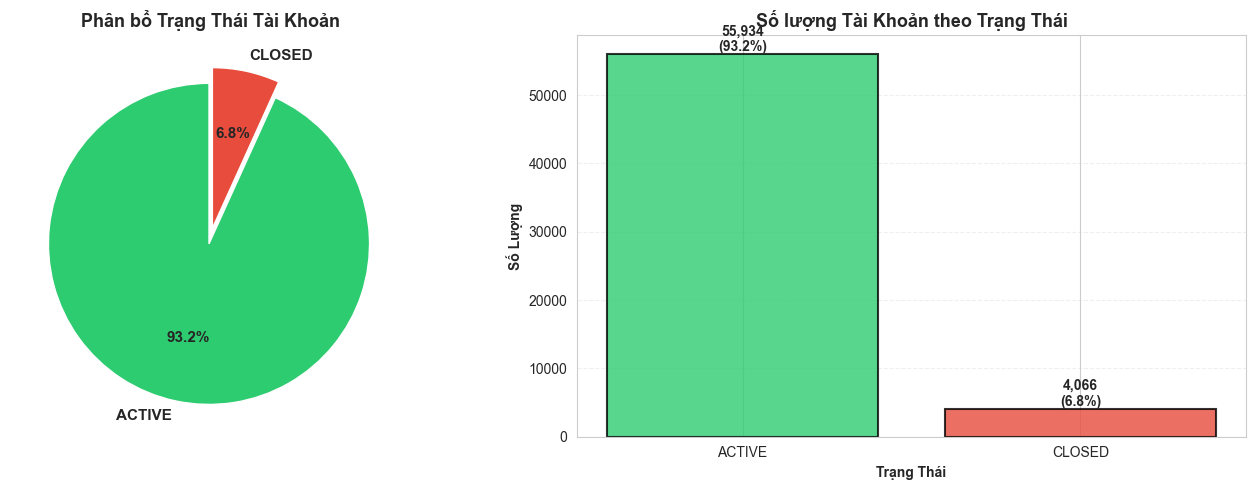


YẾU TỐ 2: ĐỘ TUỔI TÀI KHOẢN (ACCOUNT AGE)

📊 Thống kê độ tuổi tài khoản:
  - Trung bình (Mean):  5.41 năm
  - Trung vị (Median):  5.42 năm
  - Độ lệch chuẩn:      3.15 năm
  - Min:                0.00 năm
  - Max:                10.95 năm

📊 Phân bổ theo nhóm độ tuổi:
  - 0-2 năm   : 10,927 tài khoản (18.21%)
  - 2-5 năm   : 16,453 tài khoản (27.42%)
  - 5-8 năm   : 16,667 tài khoản (27.78%)
  - 8-11 năm  : 15,652 tài khoản (26.09%)


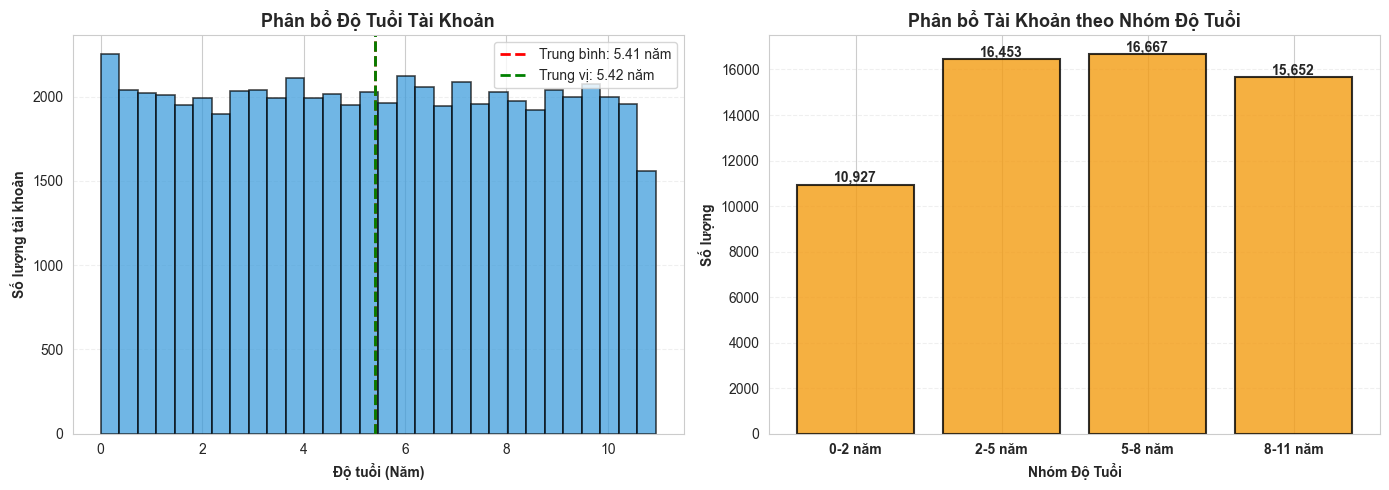


PHÂN TÍCH MỐI QUAN HỆ: ACCOUNT STATUS vs ACCOUNT AGE

📊 Mối quan hệ giữa Trạng Thái và Độ Tuổi Tài Khoản:
age_group       0-2 năm  2-5 năm  5-8 năm  8-11 năm    All
account_status                                            
ACTIVE            10194    15270    15529     14663  55656
CLOSED              733     1183     1138       989   4043
All               10927    16453    16667     15652  59699


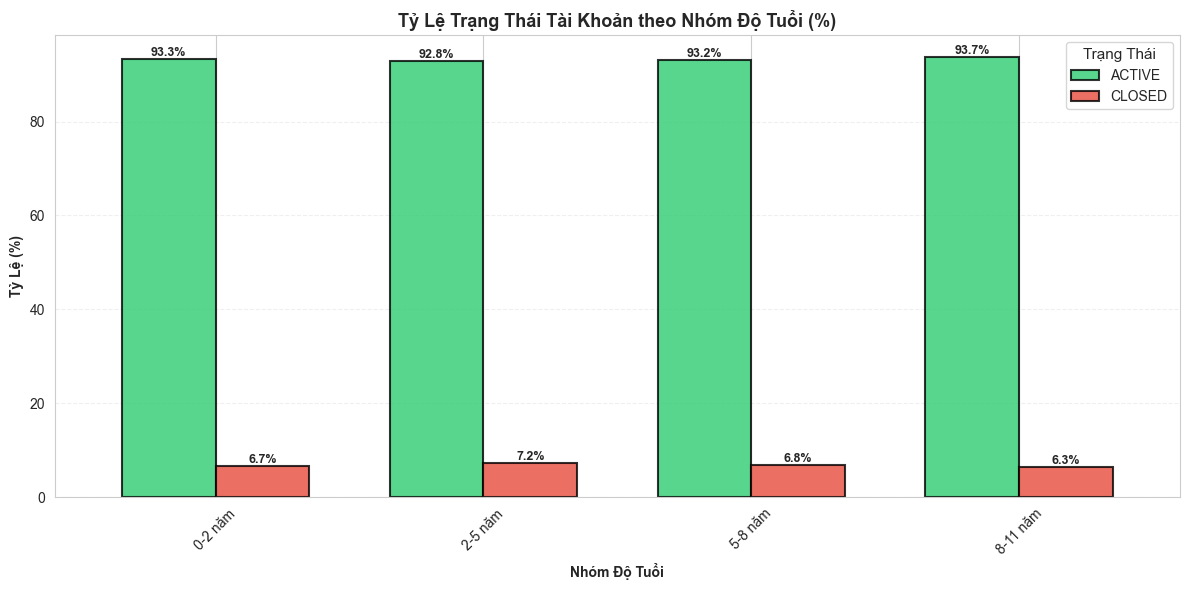


📊 Tỷ lệ ACTIVE theo nhóm độ tuổi:
  - 0-2 năm   : 93.29% Active,  6.71% Closed
  - 2-5 năm   : 92.81% Active,  7.19% Closed
  - 5-8 năm   : 93.17% Active,  6.83% Closed
  - 8-11 năm  : 93.68% Active,  6.32% Closed


In [13]:
# 2.1 - Phân tích Account Data - Tập trung vào các yếu tố có sự khác biệt
print("="*70)
print("PHẦN 2.1 - PHÂN TÍCH TÀI KHOẢN (ACCOUNT) ")
print("="*70)

# Thông tin cơ bản
print(f"\n📊 TỔNG QUAN DỮ LIỆU ACCOUNT:")
print(f"  - Tổng số tài khoản: {len(df_account):,}")
print(f"  - Số khách hàng: {df_account['customer_id'].nunique():,}")

# Kiểm tra chất lượng dữ liệu
print(f"\n🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:")
missing_account = df_account.isnull().sum()
duplicates_account = df_account.duplicated().sum()
print(f"  - Missing values: {missing_account.sum()} ✓")
print(f"  - Duplicates: {duplicates_account} ✓")

print(f"\n{'='*70}")
print("YẾU TỐ 1: TRẠNG THÁI TÀI KHOẢN (ACCOUNT STATUS)")
print(f"{'='*70}")

account_status_dist = df_account['account_status'].value_counts()
account_status_pct = df_account['account_status'].value_counts(normalize=True) * 100

print(f"\n📈 Phân bổ trạng thái:")
for status in account_status_dist.index:
    count = account_status_dist[status]
    pct = account_status_pct[status]
    print(f"  - {status:10s}: {count:6,} khách hàng ({pct:5.2f}%)")

# Biểu đồ trạng thái tài khoản
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(account_status_dist.values, 
                                         labels=account_status_dist.index,
                                         autopct='%1.1f%%',
                                         colors=colors[:len(account_status_dist)],
                                         startangle=90,
                                         explode=(0.05, 0.05),
                                         textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Phân bổ Trạng Thái Tài Khoản', fontweight='bold', fontsize=13)

# Bar chart
bars = axes[1].bar(account_status_dist.index, account_status_dist.values, 
                   color=colors[:len(account_status_dist)], edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_title('Số lượng Tài Khoản theo Trạng Thái', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Trạng Thái', fontweight='bold')
axes[1].set_ylabel('Số Lượng', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Thêm giá trị trên cột
for bar, value in zip(bars, account_status_dist.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(value):,}\n({value/len(df_account)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("YẾU TỐ 2: ĐỘ TUỔI TÀI KHOẢN (ACCOUNT AGE)")
print(f"{'='*70}")

# Tính toán account age
df_account['account_age_days'] = (df_account['open_date'].max() - df_account['open_date']).dt.days
df_account['account_age_years'] = df_account['account_age_days'] / 365.25

# Thống kê độ tuổi
age_stats = df_account['account_age_years'].describe()
print(f"\n📊 Thống kê độ tuổi tài khoản:")
print(f"  - Trung bình (Mean):  {age_stats['mean']:.2f} năm")
print(f"  - Trung vị (Median):  {df_account['account_age_years'].median():.2f} năm")
print(f"  - Độ lệch chuẩn:      {age_stats['std']:.2f} năm")
print(f"  - Min:                {age_stats['min']:.2f} năm")
print(f"  - Max:                {age_stats['max']:.2f} năm")

# Chia độ tuổi thành các nhóm
df_account['age_group'] = pd.cut(df_account['account_age_years'],
                                   bins=[0, 2, 5, 8, 11],
                                   labels=['0-2 năm', '2-5 năm', '5-8 năm', '8-11 năm'])
age_group_dist = df_account['age_group'].value_counts().sort_index()

print(f"\n📊 Phân bổ theo nhóm độ tuổi:")
for group in age_group_dist.index:
    count = age_group_dist[group]
    pct = (count / len(df_account)) * 100
    print(f"  - {group:10s}: {count:6,} tài khoản ({pct:5.2f}%)")

# Biểu đồ độ tuổi tài khoản
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_account['account_age_years'], bins=30, color='#3498db', 
            edgecolor='black', alpha=0.7, linewidth=1.2)
axes[0].axvline(df_account['account_age_years'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f"Trung bình: {df_account['account_age_years'].mean():.2f} năm")
axes[0].axvline(df_account['account_age_years'].median(), color='green', linestyle='--',
               linewidth=2, label=f"Trung vị: {df_account['account_age_years'].median():.2f} năm")
axes[0].set_title('Phân bổ Độ Tuổi Tài Khoản', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Độ tuổi (Năm)', fontweight='bold')
axes[0].set_ylabel('Số lượng tài khoản', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Bar chart cho age groups
bars = axes[1].bar(range(len(age_group_dist)), age_group_dist.values, 
                   color='#f39c12', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xticks(range(len(age_group_dist)))
axes[1].set_xticklabels(age_group_dist.index, fontsize=10, fontweight='bold')
axes[1].set_title('Phân bổ Tài Khoản theo Nhóm Độ Tuổi', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Nhóm Độ Tuổi', fontweight='bold')
axes[1].set_ylabel('Số lượng', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Thêm giá trị trên cột
for bar, value in zip(bars, age_group_dist.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(value):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("PHÂN TÍCH MỐI QUAN HỆ: ACCOUNT STATUS vs ACCOUNT AGE")
print(f"{'='*70}")

# Crosswalk giữa Status và Age Group
crosstab = pd.crosstab(df_account['account_status'], df_account['age_group'], margins=True)
print(f"\n📊 Mối quan hệ giữa Trạng Thái và Độ Tuổi Tài Khoản:")
print(crosstab)

# Tính tỷ lệ Active/Closed theo age group
fig, ax = plt.subplots(figsize=(12, 6))

age_status_analysis = pd.crosstab(df_account['age_group'], 
                                   df_account['account_status'], 
                                   normalize='index') * 100

age_status_analysis.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                         edgecolor='black', linewidth=1.5, alpha=0.8, width=0.7)
ax.set_title('Tỷ Lệ Trạng Thái Tài Khoản theo Nhóm Độ Tuổi (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('Nhóm Độ Tuổi', fontweight='bold')
ax.set_ylabel('Tỷ Lệ (%)', fontweight='bold')
ax.legend(title='Trạng Thái', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Thêm giá trị trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# In ra phân tích chi tiết
print(f"\n📊 Tỷ lệ ACTIVE theo nhóm độ tuổi:")
for age_group in age_status_analysis.index:
    active_pct = age_status_analysis.loc[age_group, 'ACTIVE']
    closed_pct = age_status_analysis.loc[age_group, 'CLOSED']
    print(f"  - {age_group:10s}: {active_pct:5.2f}% Active, {closed_pct:5.2f}% Closed")


PHẦN 2.2 - PHÂN TÍCH SỐ DƯ (BALANCE) 

📊 TỔNG QUAN DỮ LIỆU BALANCE:
  - Tổng bản ghi balance: 1,440,000

🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:
  - Missing values: 0 ✓
  - Duplicates: 0 ✓

YẾU TỐ 1: PHÂN BỐ SỐ DƯ (BALANCE DISTRIBUTION)


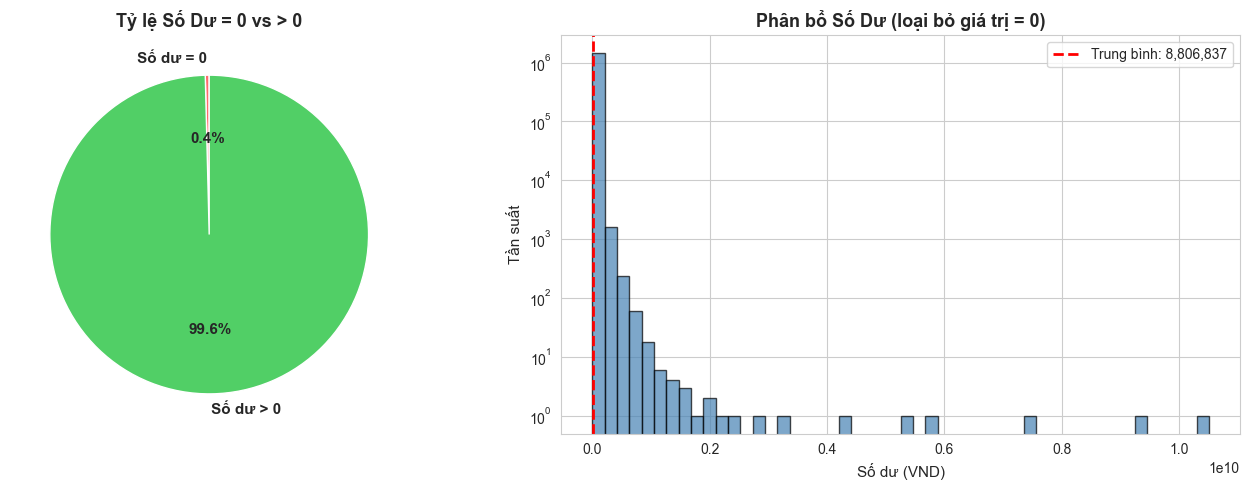


📈 Phân bổ số dư:
  - Bản ghi có số dư = 0  : 5,677 bản ghi (0.39%)
  - Bản ghi có số dư > 0  : 1,434,323 bản ghi (99.61%)

📊 Thống kê Số Dư (khi > 0):
  - Trung bình (Mean)    : 8,806,837 VND
  - Trung vị (Median)    : 3,814,329 VND
  - Độ lệch chuẩn (Std)  : 25,370,461 VND
  - Min                  : 0 VND
  - Max                  : 10,506,464,007 VND


In [14]:
# 2.2 - Phân tích Balance Data 
print("\n" + "="*70)
print("PHẦN 2.2 - PHÂN TÍCH SỐ DƯ (BALANCE) ")
print("="*70)

# Kiểm tra chất lượng dữ liệu
print(f"\n📊 TỔNG QUAN DỮ LIỆU BALANCE:")
print(f"  - Tổng bản ghi balance: {len(df_balance_snapshots):,}")
print(f"\n🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:")
print(f"  - Missing values: {df_balance_snapshots.isnull().sum().sum()} ✓")
print(f"  - Duplicates: {df_balance_snapshots.duplicated().sum()} ✓")

# YẾU TỐ 1: PHÂN BỐ SỐ DƯ (CÓ SỰ KHÁC BIỆT - 0 vs > 0)
zero_count = (df_balance_snapshots['balance'] == 0).sum()
positive_count = (df_balance_snapshots['balance'] > 0).sum()
balance_stats = df_balance_snapshots['balance'].describe()

print(f"\n" + "="*70)
print(f"YẾU TỐ 1: PHÂN BỐ SỐ DƯ (BALANCE DISTRIBUTION)")
print(f"="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - Zero vs Positive
axes[0].pie([zero_count, positive_count], 
           labels=['Số dư = 0', 'Số dư > 0'],
           autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], startangle=90,
           textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Tỷ lệ Số Dư = 0 vs > 0', fontweight='bold', fontsize=13)

# Histogram - Phân bổ chi tiết (loại bỏ 0)
balance_clean = df_balance_snapshots[df_balance_snapshots['balance'] > 0]['balance']
axes[1].hist(balance_clean, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Phân bổ Số Dư (loại bỏ giá trị = 0)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Số dư (VND)', fontsize=11)
axes[1].set_ylabel('Tần suất', fontsize=11)
axes[1].set_yscale('log')
axes[1].axvline(balance_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Trung bình: {balance_stats['mean']:,.0f}")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📈 Phân bổ số dư:")
print(f"  - Bản ghi có số dư = 0  : {zero_count:,} bản ghi ({zero_count/len(df_balance_snapshots)*100:.2f}%)")
print(f"  - Bản ghi có số dư > 0  : {positive_count:,} bản ghi ({positive_count/len(df_balance_snapshots)*100:.2f}%)")

print(f"\n📊 Thống kê Số Dư (khi > 0):")
print(f"  - Trung bình (Mean)    : {balance_stats['mean']:,.0f} VND")
print(f"  - Trung vị (Median)    : {balance_stats['50%']:,.0f} VND")
print(f"  - Độ lệch chuẩn (Std)  : {balance_stats['std']:,.0f} VND")
print(f"  - Min                  : {balance_stats['min']:,.0f} VND")
print(f"  - Max                  : {balance_stats['max']:,.0f} VND")


PHẦN 2.3 - PHÂN TÍCH GIAO DỊCH (TRANSACTION) 

📊 TỔNG QUAN DỮ LIỆU TRANSACTION:
  - Tổng giao dịch: 9,757,050
  - Số tài khoản có giao dịch: 59,996

YẾU TỐ 1: PHÂN BỐ LOẠI GIAO DỊCH (TRANSACTION TYPE)


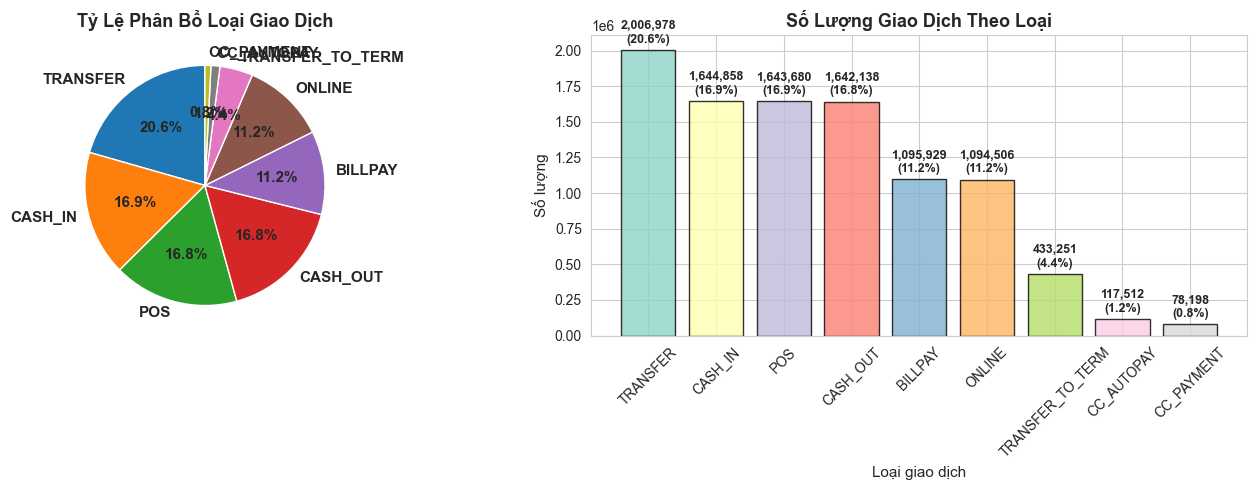


📈 Phân bổ loại giao dịch:
  - TRANSFER: 2,006,978 giao dịch (20.57%)
  - CASH_IN: 1,644,858 giao dịch (16.86%)
  - POS: 1,643,680 giao dịch (16.85%)
  - CASH_OUT: 1,642,138 giao dịch (16.83%)
  - BILLPAY: 1,095,929 giao dịch (11.23%)
  - ONLINE: 1,094,506 giao dịch (11.22%)
  - TRANSFER_TO_TERM: 433,251 giao dịch (4.44%)
  - CC_AUTOPAY: 117,512 giao dịch (1.20%)
  - CC_PAYMENT: 78,198 giao dịch (0.80%)

YẾU TỐ 2: PHÂN BỐ SỐ TIỀN GIAO DỊCH (TRANSACTION AMOUNT)


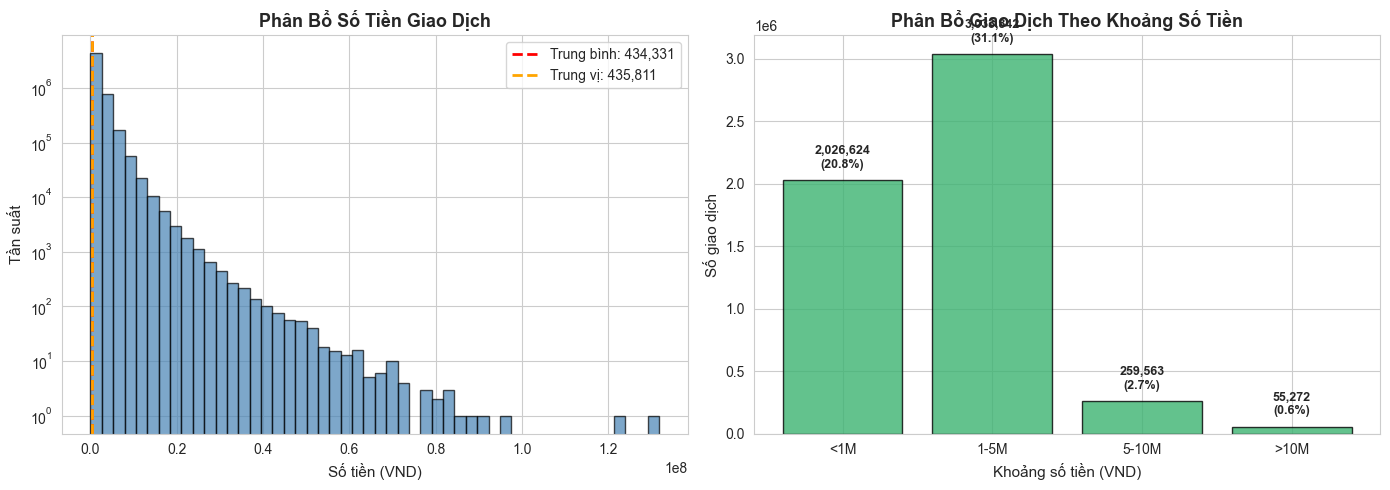


📊 Thống kê Số Tiền Giao Dịch:
  - Trung bình (Mean): 434,331 VND
  - Trung vị (Median): 435,811 VND
  - Độ lệch chuẩn (Std): 2,392,256 VND
  - Min: -57,531,162 VND
  - Max: 131,796,649 VND

📊 Phân bổ theo khoảng số tiền:
  - <1M: 2,026,624 giao dịch (20.77%)
  - 1-5M: 3,033,842 giao dịch (31.09%)
  - 5-10M: 259,563 giao dịch (2.66%)
  - >10M: 55,272 giao dịch (0.57%)

YẾU TỐ 3: PHÂN BỐ SỐ GIAO DỊCH TRÊN MỖI TÀI KHOẢN (TRANSACTIONS PER ACCOUNT)


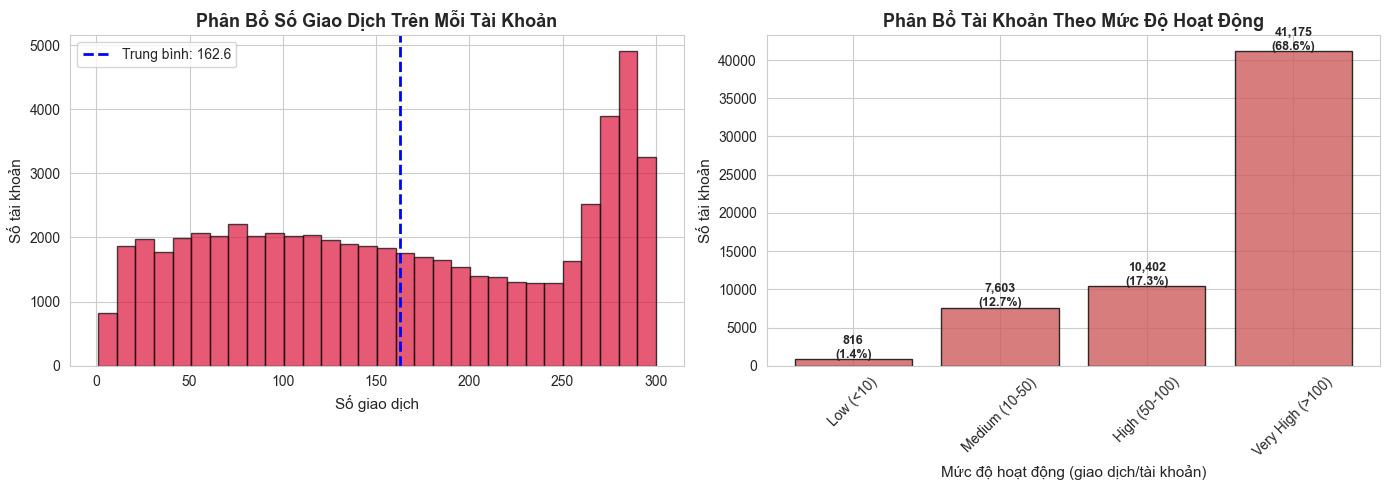


📊 Thống kê Số Giao Dịch/Tài Khoản:
  - Trung bình (Mean): 162.63 giao dịch/tài khoản
  - Trung vị (Median): 158 giao dịch/tài khoản
  - Độ lệch chuẩn (Std): 91.53
  - Min: 1 giao dịch/tài khoản
  - Max: 300 giao dịch/tài khoản

📊 Phân bổ theo mức độ hoạt động:
  - Low (<10): 816 tài khoản (1.36%)
  - Medium (10-50): 7,603 tài khoản (12.67%)
  - High (50-100): 10,402 tài khoản (17.34%)
  - Very High (>100): 41,175 tài khoản (68.63%)


In [15]:
# 2.3 - Phân tích Transaction Data 
print("\n" + "="*70)
print("PHẦN 2.3 - PHÂN TÍCH GIAO DỊCH (TRANSACTION) ")
print("="*70)

# Kiểm tra chất lượng dữ liệu
print(f"\n📊 TỔNG QUAN DỮ LIỆU TRANSACTION:")
print(f"  - Tổng giao dịch: {len(df_transactions):,}")
print(f"  - Số tài khoản có giao dịch: {df_transactions['account_id'].nunique():,}")

# Y̾Ế TỐ 1: PHÂN BỐ LOẠI GIAO DỊCH (CÓ SỰ KHÁC BIỆT)
print(f"\n" + "="*70)
print(f"YẾU TỐ 1: PHÂN BỐ LOẠI GIAO DỊCH (TRANSACTION TYPE)")
print(f"="*70)

txn_type_dist = df_transactions['transaction_type'].value_counts()
txn_type_pct = (txn_type_dist / len(df_transactions) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(txn_type_dist.values, labels=txn_type_dist.index, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Tỷ Lệ Phân Bổ Loại Giao Dịch', fontweight='bold', fontsize=13)

# Bar chart
colors_txn = plt.cm.Set3(range(len(txn_type_dist)))
axes[1].bar(txn_type_dist.index, txn_type_dist.values, color=colors_txn, edgecolor='black', alpha=0.8)
axes[1].set_title('Số Lượng Giao Dịch Theo Loại', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Loại giao dịch', fontsize=11)
axes[1].set_ylabel('Số lượng', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(txn_type_dist.values):
    axes[1].text(i, v + 50000, f'{v:,}\n({txn_type_pct[i]:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📈 Phân bổ loại giao dịch:")
for txn_type, count in txn_type_dist.items():
    pct = count / len(df_transactions) * 100
    print(f"  - {txn_type}: {count:,} giao dịch ({pct:.2f}%)")

# YẾU TỐ 2: PHÂN BỐ SỐ TIỀN GIAO DỊCH (CÓ SỰ KHÁC BIỆT)
print(f"\n" + "="*70)
print(f"YẾU TỐ 2: PHÂN BỐ SỐ TIỀN GIAO DỊCH (TRANSACTION AMOUNT)")
print(f"="*70)

txn_amount_stats = df_transactions['amount'].describe()
txn_amount_clean = df_transactions[df_transactions['amount'] > 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(txn_amount_clean, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân Bổ Số Tiền Giao Dịch', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Số tiền (VND)', fontsize=11)
axes[0].set_ylabel('Tần suất', fontsize=11)
axes[0].set_yscale('log')
axes[0].axvline(txn_amount_stats['mean'], color='red', linestyle='--', linewidth=2, 
               label=f"Trung bình: {txn_amount_stats['mean']:,.0f}")
axes[0].axvline(txn_amount_stats['50%'], color='orange', linestyle='--', linewidth=2, 
               label=f"Trung vị: {txn_amount_stats['50%']:,.0f}")
axes[0].legend(fontsize=10)

# Amount groups
df_transactions['amount_group'] = pd.cut(df_transactions['amount'], 
                                         bins=[0, 1000000, 5000000, 10000000, 100000000],
                                         labels=['<1M', '1-5M', '5-10M', '>10M'])
amount_group_dist = df_transactions['amount_group'].value_counts().sort_index()
amount_group_pct = (amount_group_dist / len(df_transactions) * 100).round(2)

axes[1].bar(amount_group_dist.index, amount_group_dist.values, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Phân Bổ Giao Dịch Theo Khoảng Số Tiền', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Khoảng số tiền (VND)', fontsize=11)
axes[1].set_ylabel('Số giao dịch', fontsize=11)
for i, v in enumerate(amount_group_dist.values):
    axes[1].text(i, v + 100000, f'{v:,}\n({amount_group_pct[i]:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Thống kê Số Tiền Giao Dịch:")
print(f"  - Trung bình (Mean): {txn_amount_stats['mean']:,.0f} VND")
print(f"  - Trung vị (Median): {txn_amount_stats['50%']:,.0f} VND")
print(f"  - Độ lệch chuẩn (Std): {txn_amount_stats['std']:,.0f} VND")
print(f"  - Min: {txn_amount_stats['min']:,.0f} VND")
print(f"  - Max: {txn_amount_stats['max']:,.0f} VND")

print(f"\n📊 Phân bổ theo khoảng số tiền:")
for amount_group, count in amount_group_dist.items():
    pct = count / len(df_transactions) * 100
    print(f"  - {amount_group}: {count:,} giao dịch ({pct:.2f}%)")

# YẾU TỐ 3: PHÂN BỐ SỐ GIAO DỊCH TRÊN MỖI TÀI KHOẢN (CÓ SỰ KHÁC BIỆT)
print(f"\n" + "="*70)
print(f"YẾU TỐ 3: PHÂN BỐ SỐ GIAO DỊCH TRÊN MỖI TÀI KHOẢN (TRANSACTIONS PER ACCOUNT)")
print(f"="*70)

txn_per_account = df_transactions.groupby('account_id').size()
txn_per_account_stats = txn_per_account.describe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(txn_per_account, bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân Bổ Số Giao Dịch Trên Mỗi Tài Khoản', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Số giao dịch', fontsize=11)
axes[0].set_ylabel('Số tài khoản', fontsize=11)
axes[0].axvline(txn_per_account_stats['mean'], color='blue', linestyle='--', linewidth=2,
               label=f"Trung bình: {txn_per_account_stats['mean']:.1f}")
axes[0].legend(fontsize=10)

# Activity groups
df_txn_activity = pd.DataFrame({'account_id': txn_per_account.index, 'txn_count': txn_per_account.values})
df_txn_activity['activity_group'] = pd.cut(df_txn_activity['txn_count'],
                                           bins=[0, 10, 50, 100, 10000],
                                           labels=['Low (<10)', 'Medium (10-50)', 'High (50-100)', 'Very High (>100)'])
activity_dist = df_txn_activity['activity_group'].value_counts().sort_index()
activity_pct = (activity_dist / len(txn_per_account) * 100).round(2)

axes[1].bar(activity_dist.index, activity_dist.values, color='indianred', edgecolor='black', alpha=0.8)
axes[1].set_title('Phân Bổ Tài Khoản Theo Mức Độ Hoạt Động', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Mức độ hoạt động (giao dịch/tài khoản)', fontsize=11)
axes[1].set_ylabel('Số tài khoản', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(activity_dist.values):
    axes[1].text(i, v + 200, f'{v:,}\n({activity_pct[i]:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Thống kê Số Giao Dịch/Tài Khoản:")
print(f"  - Trung bình (Mean): {txn_per_account_stats['mean']:.2f} giao dịch/tài khoản")
print(f"  - Trung vị (Median): {txn_per_account_stats['50%']:.0f} giao dịch/tài khoản")
print(f"  - Độ lệch chuẩn (Std): {txn_per_account_stats['std']:.2f}")
print(f"  - Min: {txn_per_account_stats['min']:.0f} giao dịch/tài khoản")
print(f"  - Max: {txn_per_account_stats['max']:.0f} giao dịch/tài khoản")

print(f"\n📊 Phân bổ theo mức độ hoạt động:")
for activity, count in activity_dist.items():
    pct = count / len(txn_per_account) * 100
    print(f"  - {activity}: {count:,} tài khoản ({pct:.2f}%)")


PHẦN 2.4 - PHÂN TÍCH THẺ TÍN DỤNG (CREDIT CARDS) 

📊 TỔNG QUAN DỮ LIỆU CREDIT CARDS:
  - Tổng số thẻ: 60,000
  - Số khách hàng có thẻ: 60,000

🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:
  - Missing values: 71978
  - Duplicates: 0 ✓

YẾU TỐ 1: PHÂN BỐ TRẠNG THÁI THẺ (CARD STATUS)


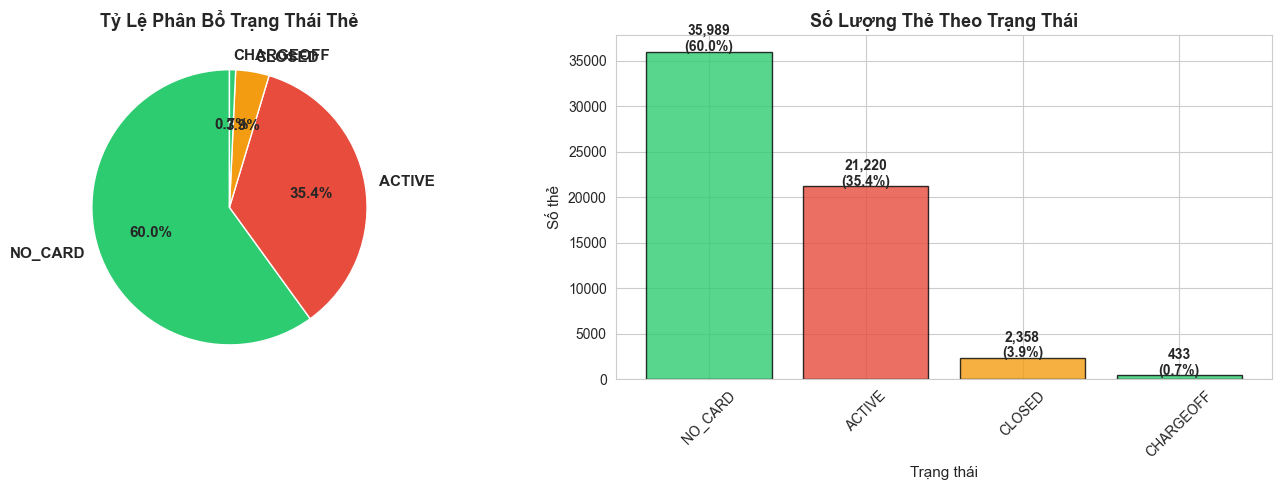


📈 Phân bổ trạng thái thẻ:
  - NO_CARD: 35,989 thẻ (59.98%)
  - ACTIVE: 21,220 thẻ (35.37%)
  - CLOSED: 2,358 thẻ (3.93%)
  - CHARGEOFF: 433 thẻ (0.72%)

YẾU TỐ 2: PHÂN BỐ HẠN MỨC TÍN DỤNG (CREDIT LIMIT)


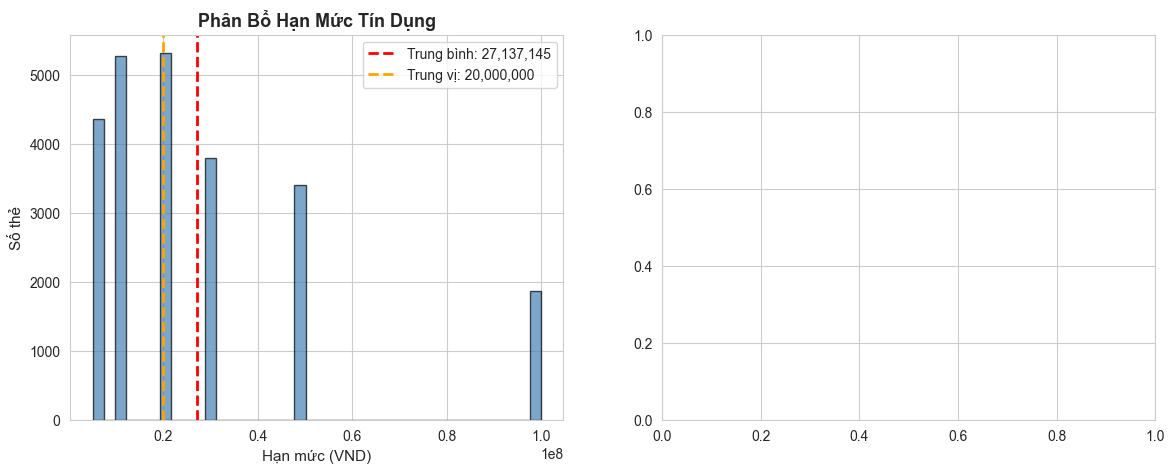

In [16]:
# 2.4 - Phân tích Credit Cards Data
print("\n" + "="*70)
print("PHẦN 2.4 - PHÂN TÍCH THẺ TÍN DỤNG (CREDIT CARDS) ")
print("="*70)

# Kiểm tra chất lượng dữ liệu
print(f"\n📊 TỔNG QUAN DỮ LIỆU CREDIT CARDS:")
print(f"  - Tổng số thẻ: {len(df_credit_cards):,}")
print(f"  - Số khách hàng có thẻ: {df_credit_cards['customer_id'].nunique():,}")
print(f"\n🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:")
print(f"  - Missing values: {df_credit_cards.isnull().sum().sum()}")
print(f"  - Duplicates: {df_credit_cards.duplicated().sum()} ✓")

# YẾU TỐ 1: PHÂN BỐ TRẠNG THÁI THẺ (CÓ SỰ KHÁC BIỆT)
if 'card_status' in df_credit_cards.columns:
    print(f"\n" + "="*70)
    print(f"YẾU TỐ 1: PHÂN BỐ TRẠNG THÁI THẺ (CARD STATUS)")
    print(f"="*70)
    
    card_status_dist = df_credit_cards['card_status'].value_counts()
    card_status_pct = (card_status_dist / len(df_credit_cards) * 100).round(2)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    colors_status = ['#2ecc71', '#e74c3c', '#f39c12']
    axes[0].pie(card_status_dist.values, labels=card_status_dist.index, autopct='%1.1f%%',
               colors=colors_status[:len(card_status_dist)], startangle=90, 
               textprops={'fontsize': 11, 'weight': 'bold'})
    axes[0].set_title('Tỷ Lệ Phân Bổ Trạng Thái Thẻ', fontweight='bold', fontsize=13)
    
    # Bar chart
    axes[1].bar(card_status_dist.index, card_status_dist.values, color=colors_status[:len(card_status_dist)],
               edgecolor='black', alpha=0.8)
    axes[1].set_title('Số Lượng Thẻ Theo Trạng Thái', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Trạng thái', fontsize=11)
    axes[1].set_ylabel('Số thẻ', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(card_status_dist.values):
        axes[1].text(i, v + 50, f'{v:,}\n({card_status_pct[i]:.1f}%)', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📈 Phân bổ trạng thái thẻ:")
    for status, count in card_status_dist.items():
        pct = count / len(df_credit_cards) * 100
        print(f"  - {status}: {count:,} thẻ ({pct:.2f}%)")

# YẾU TỐ 2: PHÂN BỐ HẠNMỨC TÍN DỤNG (CÓ SỰ KHÁC BIỆT)
if 'credit_limit' in df_credit_cards.columns:
    print(f"\n" + "="*70)
    print(f"YẾU TỐ 2: PHÂN BỐ HẠN MỨC TÍN DỤNG (CREDIT LIMIT)")
    print(f"="*70)
    
    credit_limit_stats = df_credit_cards['credit_limit'].describe()
    # Loại bỏ các giá trị null
    credit_limit_clean = df_credit_cards[df_credit_cards['credit_limit'].notna()]['credit_limit']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(credit_limit_clean, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Phân Bổ Hạn Mức Tín Dụng', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Hạn mức (VND)', fontsize=11)
    axes[0].set_ylabel('Số thẻ', fontsize=11)
    axes[0].axvline(credit_limit_stats['mean'], color='red', linestyle='--', linewidth=2,
                   label=f"Trung bình: {credit_limit_stats['mean']:,.0f}")
    axes[0].axvline(credit_limit_stats['50%'], color='orange', linestyle='--', linewidth=2,
                   label=f"Trung vị: {credit_limit_stats['50%']:,.0f}")
    axes[0].legend(fontsize=10)
    
    # Credit limit groups
    df_credit_cards_temp = df_credit_cards.copy()
    df_credit_cards_temp['limit_group'] = pd.cut(df_credit_cards_temp['credit_limit'],
                                                  bins=[0, 5000000, 10000000, 20000000, 100000000],
                                                  labels=['<5M', '5-10M', '10-20M', '>20M'])

---
## Phần 3: Định Nghĩa Nhãn Churn & Xây Dựng Hàm Phân Loại
Dựa trên logic từ `build_churn_labels_Ver2.py` - 6 quy tắc churn kết hợp

In [3]:
# ==================================================
# PHẦN 3: ĐỊNH NGHĨA NHÃN CHURN & PHÂN LOẠI KHÁCH HÀNG
# ==================================================
# Dựa trên logic từ build_churn_labels_Ver2.py

print("="*70)
print("PHẦN 3: ĐỊNH NGHĨA NHÃN CHURN & PHÂN LOẠI KHÁCH HÀNG")
print("="*70)

# ==================================================
# CONFIG - THRESHOLDS & PARAMETERS
# ==================================================
AS_OF_DATE = pd.Timestamp("2025-12-31")  # Reference date

# Thresholds (theo rule đã thống nhất)
INACTIVE_DAYS = 180
LOW_BALANCE_THRESHOLD = 1_000_000
TRANSFER_TO_TERM_RATIO = 0.90
CC_DELINQUENCY_RISK = 60

# ==================================================
# STEP 1: TẠO BASE DATAFRAME - MERGE TẤT CẢ DỮ LIỆU
# ==================================================
df = (
    df_account
    .merge(df_customer, on='customer_id', how='left')
    .merge(df_credit_cards, on='customer_id', how='left')
)

print(f"\n✅ Base DataFrame created: {df.shape}")
print(f"   Columns: {df.shape[1]}")

# ==================================================
# FEATURE 1: DAYS_SINCE_LAST_TRANSACTION
# ==================================================
print("\n" + "-"*70)
print("FEATURE 1: TÍNH DAYS_SINCE_LAST_TRANSACTION")
print("-"*70)

# Chuyển đổi ngày tháng
df_transactions['transaction_datetime'] = pd.to_datetime(df_transactions['transaction_datetime'])

# Tìm giao dịch gần nhất cho mỗi account
last_txn = (
    df_transactions
    .groupby('account_id')['transaction_datetime']
    .max()
)

# Tính days_since_last_txn
df['days_since_last_txn'] = (
    AS_OF_DATE - df['account_id'].map(last_txn)
).dt.days

# Flag inactive (no transaction in 180 days)
df['inactive_6m'] = (df['days_since_last_txn'] >= INACTIVE_DAYS).astype(int)

inactive_count = df['inactive_6m'].sum()
print(f"✓ Inactive accounts (>= {INACTIVE_DAYS} days): {inactive_count:,}")

# ==================================================
# FEATURE 2: LOW BALANCE FOR 3 MONTHS
# ==================================================
print("\n" + "-"*70)
print("FEATURE 2: LOW BALANCE FOR LAST 3 MONTHS")
print("-"*70)

df_balance_snapshots['snapshot_date'] = pd.to_datetime(df_balance_snapshots['snapshot_date'])

# Lấy 3 snapshots gần nhất (cuối cùng 3 tháng)
last_3_months = (
    df_balance_snapshots.loc[df_balance_snapshots['snapshot_date'] <= AS_OF_DATE]
    .sort_values('snapshot_date')
    .groupby('account_id')
    .tail(3)
)

# Kiểm tra nếu ALL 3 snapshots có balance < threshold
low_balance_3m = (
    last_3_months
    .assign(low=lambda x: x['balance'] < LOW_BALANCE_THRESHOLD)
    .groupby('account_id')['low']
    .all()
)

df['balance_low_3m'] = df['account_id'].map(low_balance_3m).fillna(False).astype(int)

low_balance_count = df['balance_low_3m'].sum()
print(f"✓ Accounts with low balance (<{LOW_BALANCE_THRESHOLD:,}) for 3 months: {low_balance_count:,}")

# ==================================================
# FEATURE 3: BALANCE DROP (3 MONTHS)
# ==================================================
print("\n" + "-"*70)
print("FEATURE 3: BALANCE DROP (LAST 3 MONTHS)")
print("-"*70)

# Latest balance (last snapshot)
bal_last = (
    df_balance_snapshots[df_balance_snapshots['snapshot_date'] <= AS_OF_DATE]
    .sort_values('snapshot_date')
    .groupby('account_id')
    .tail(1)
    .set_index('account_id')['balance']
)

# Previous balance (4th snapshot from latest)
bal_prev = (
    df_balance_snapshots[df_balance_snapshots['snapshot_date'] <= AS_OF_DATE]
    .sort_values('snapshot_date')
    .groupby('account_id')
    .nth(-4)
    .set_index('account_id')['balance']
)

# Calculate balance drop percentage
balance_drop_3m = (bal_last - bal_prev) / bal_prev.replace(0, np.nan)

df['balance_drop_3m'] = df['account_id'].map(balance_drop_3m)

balance_drop_count = (df['balance_drop_3m'] <= -0.5).sum()
print(f"✓ Accounts with balance drop >= 50%: {balance_drop_count:,}")

# ==================================================
# FEATURE 4: TRANSFER TO TERM RATIO (3M)
# ==================================================
print("\n" + "-"*70)
print("FEATURE 4: TRANSFER TO TERM RATIO (LAST 3 MONTHS)")
print("-"*70)

# Lọc transactions 3 tháng gần nhất
tx_3m = df_transactions[
    df_transactions['transaction_datetime'] >= AS_OF_DATE - pd.Timedelta(days=90)
]

# Tính tổng tiền chuyển sang TERM
term_amt = (
    tx_3m[tx_3m['transaction_type'] == 'TRANSFER_TO_TERM']
    .groupby('account_id')['amount']
    .sum()
)

# Tính tổng tiền inflow (amount > 0)
inflow_amt = (
    tx_3m[tx_3m['amount'] > 0]
    .groupby('account_id')['amount']
    .sum()
)

# Tính ratio
transfer_ratio = term_amt / inflow_amt.replace(0, np.nan)

df['transfer_to_term_ratio_3m'] = (
    df['account_id'].map(transfer_ratio).fillna(0)
)

df['transfer_to_term_flag'] = (
    df['transfer_to_term_ratio_3m'] >= TRANSFER_TO_TERM_RATIO
).astype(int)

transfer_flag_count = df['transfer_to_term_flag'].sum()
print(f"✓ Accounts with transfer to term ratio >= {TRANSFER_TO_TERM_RATIO}: {transfer_flag_count:,}")

# ==================================================
# FEATURE 5: CREDIT CARD PROTECT / RISK
# ==================================================
print("\n" + "-"*70)
print("FEATURE 5: CREDIT CARD PROTECT / RISK")
print("-"*70)

# Columns check
if 'has_credit_card' not in df.columns:
    df['has_credit_card'] = 0
if 'card_status' not in df.columns:
    df['card_status'] = 'NONE'
if 'delinquency_days' not in df.columns:
    df['delinquency_days'] = 0

# CC Protect: active card + no delinquency
df['cc_protect'] = (
    (df['has_credit_card'] == 1) &
    (df['card_status'] == 'ACTIVE') &
    (df['delinquency_days'] == 0)
).astype(int)

# CC Risk: inactive card OR high delinquency
df['cc_risk'] = (
    (df['has_credit_card'] == 1) &
    (
        (df['card_status'] != 'ACTIVE') |
        (df['delinquency_days'] >= CC_DELINQUENCY_RISK)
    )
).astype(int)

cc_protect_count = df['cc_protect'].sum()
cc_risk_count = df['cc_risk'].sum()
print(f"✓ Accounts with credit card protect: {cc_protect_count:,}")
print(f"✓ Accounts with credit card risk: {cc_risk_count:,}")

# ==================================================
# CHURN RULES (ACCOUNT LEVEL - 6 RULES)
# ==================================================
print("\n" + "="*70)
print("STEP 6: CHURN RULES (ACCOUNT LEVEL)")
print("="*70)

# Initialize churn columns
df['churn_flag'] = 0
df['churn_reason'] = 'ACTIVE'

# Rule C1 – Account CLOSED (hard churn)
print("\n" + "-"*70)
print("Rule C1: ACCOUNT_CLOSED")
print("-"*70)
mask_c1 = df['account_status'] == 'CLOSED'
df.loc[mask_c1, ['churn_flag', 'churn_reason']] = [1, 'ACCOUNT_CLOSED']
c1_count = mask_c1.sum()
print(f"✓ Accounts closed: {c1_count:,}")

# Rule C2 – Inactive churn (inactive 6M + no cc_protect)
print("\n" + "-"*70)
print("Rule C2: INACTIVE_6M")
print("-"*70)
mask_c2 = (
    (df['inactive_6m'] == 1) &
    (df['cc_protect'] == 0) &
    (df['account_status'] == 'ACTIVE')
)
df.loc[mask_c2, ['churn_flag', 'churn_reason']] = [1, 'INACTIVE_6M']
c2_count = mask_c2.sum()
print(f"✓ Accounts inactive 6M: {c2_count:,}")

# Rule C3 – Inactive + low balance
print("\n" + "-"*70)
print("Rule C3: LOW_BALANCE_AND_INACTIVE")
print("-"*70)
mask_c3 = (
    (df['inactive_6m'] == 1) &
    (df['balance_low_3m'] == 1) &
    (df['account_status'] == 'ACTIVE')
)
df.loc[mask_c3, ['churn_flag', 'churn_reason']] = [1, 'LOW_BALANCE_AND_INACTIVE']
c3_count = mask_c3.sum()
print(f"✓ Accounts inactive + low balance: {c3_count:,}")

# Rule C4 – Balance drop (abandonment)
print("\n" + "-"*70)
print("Rule C4: BALANCE_DROP")
print("-"*70)
mask_c4 = (
    (df['balance_low_3m'] == 1) &
    (df['balance_drop_3m'] <= -0.5) &
    (df['account_status'] == 'ACTIVE')
)
df.loc[mask_c4, ['churn_flag', 'churn_reason']] = [1, 'BALANCE_DROP']
c4_count = mask_c4.sum()
print(f"✓ Accounts with balance drop >= 50%: {c4_count:,}")

# Rule C5 – Transfer to term (migration)
print("\n" + "-"*70)
print("Rule C5: TRANSFER_TO_TERM")
print("-"*70)
mask_c5 = (
    (df['transfer_to_term_flag'] == 1) &
    (df['cc_protect'] == 0) &
    (df['account_status'] == 'ACTIVE')
)
df.loc[mask_c5, ['churn_flag', 'churn_reason']] = [1, 'TRANSFER_TO_TERM']
c5_count = mask_c5.sum()
print(f"✓ Accounts transfer to term: {c5_count:,}")

# Rule C6 – Credit card risk + other factors
print("\n" + "-"*70)
print("Rule C6: CC_RISK_BOOSTED")
print("-"*70)
mask_c6 = (
    (df['cc_risk'] == 1) &
    (
        (df['inactive_6m'] == 1) |
        (df['balance_low_3m'] == 1) |
        (df['transfer_to_term_flag'] == 1)
    ) &
    (df['account_status'] == 'ACTIVE')
)
df.loc[mask_c6, ['churn_flag', 'churn_reason']] = [1, 'CC_RISK_BOOSTED']
c6_count = mask_c6.sum()
print(f"✓ Accounts CC risk boosted: {c6_count:,}")

# ==================================================
# SUMMARY STATISTICS
# ==================================================
print("\n" + "="*70)
print("CHURN SUMMARY (ACCOUNT LEVEL)")
print("="*70)

churn_flag_dist = df['churn_flag'].value_counts()
print(f"\n✓ Churn Distribution:")
print(f"  - Active accounts: {churn_flag_dist.get(0, 0):,}")
print(f"  - Churned accounts: {churn_flag_dist.get(1, 0):,}")
print(f"  - Churn rate: {(churn_flag_dist.get(1, 0) / len(df) * 100):.2f}%")

print(f"\n✓ Churn Reasons:")
churn_reason_dist = df[df['churn_flag'] == 1]['churn_reason'].value_counts()
for reason, count in churn_reason_dist.items():
    pct = count / len(df[df['churn_flag'] == 1]) * 100
    print(f"  - {reason:30s}: {count:6,} ({pct:5.1f}%)")

# ==================================================
# AGGREGATE TO CUSTOMER LEVEL
# ==================================================
print("\n" + "="*70)
print("AGGREGATE CHURN TO CUSTOMER LEVEL")
print("="*70)

# Customer churn = ANY account churned
df_customer_churn = (
    df
    .groupby('customer_id')
    .agg({
        'churn_flag': 'max',           # ANY account churned
        'churn_reason': lambda x: x.iloc[0] if (df.loc[x.index, 'churn_flag'] == 1).any() else 'ACTIVE'
    })
    .reset_index()
)

df_customer_churn.columns = ['customer_id', 'is_churn', 'churn_reason']

# Thống kê customer churn
cust_churn_dist = df_customer_churn['is_churn'].value_counts()
cust_churn_count = cust_churn_dist.get(1, 0)
cust_active_count = cust_churn_dist.get(0, 0)
cust_churn_rate = cust_churn_count / len(df_customer_churn) * 100

print(f"\n✓ Customer Churn Distribution:")
print(f"  - Total customers: {len(df_customer_churn):,}")
print(f"  - Churned customers: {cust_churn_count:,} ({cust_churn_rate:.2f}%)")
print(f"  - Active customers: {cust_active_count:,} ({100-cust_churn_rate:.2f}%)")

print(f"\n✓ Customer Churn Reasons:")
cust_churn_reason_dist = df_customer_churn[df_customer_churn['is_churn'] == 1]['churn_reason'].value_counts()
for reason, count in cust_churn_reason_dist.items():
    pct = count / len(df_customer_churn[df_customer_churn['is_churn'] == 1]) * 100
    print(f"  - {reason:30s}: {count:6,} ({pct:5.1f}%)")



PHẦN 3: ĐỊNH NGHĨA NHÃN CHURN & PHÂN LOẠI KHÁCH HÀNG

✅ Base DataFrame created: (60000, 15)
   Columns: 15

----------------------------------------------------------------------
FEATURE 1: TÍNH DAYS_SINCE_LAST_TRANSACTION
----------------------------------------------------------------------
✓ Inactive accounts (>= 180 days): 367

----------------------------------------------------------------------
FEATURE 2: LOW BALANCE FOR LAST 3 MONTHS
----------------------------------------------------------------------
✓ Accounts with low balance (<1,000,000) for 3 months: 17,077

----------------------------------------------------------------------
FEATURE 3: BALANCE DROP (LAST 3 MONTHS)
----------------------------------------------------------------------
✓ Accounts with balance drop >= 50%: 5,881

----------------------------------------------------------------------
FEATURE 4: TRANSFER TO TERM RATIO (LAST 3 MONTHS)
----------------------------------------------------------------------
✓ 


VISUALIZATION - PHÂN BỐ CHURN

✓ Customer-level churn distribution:
  - Total customers: 60,000
  - Churned customers: 6,168 (10.3%)
  - Active customers: 53,832 (89.7%)


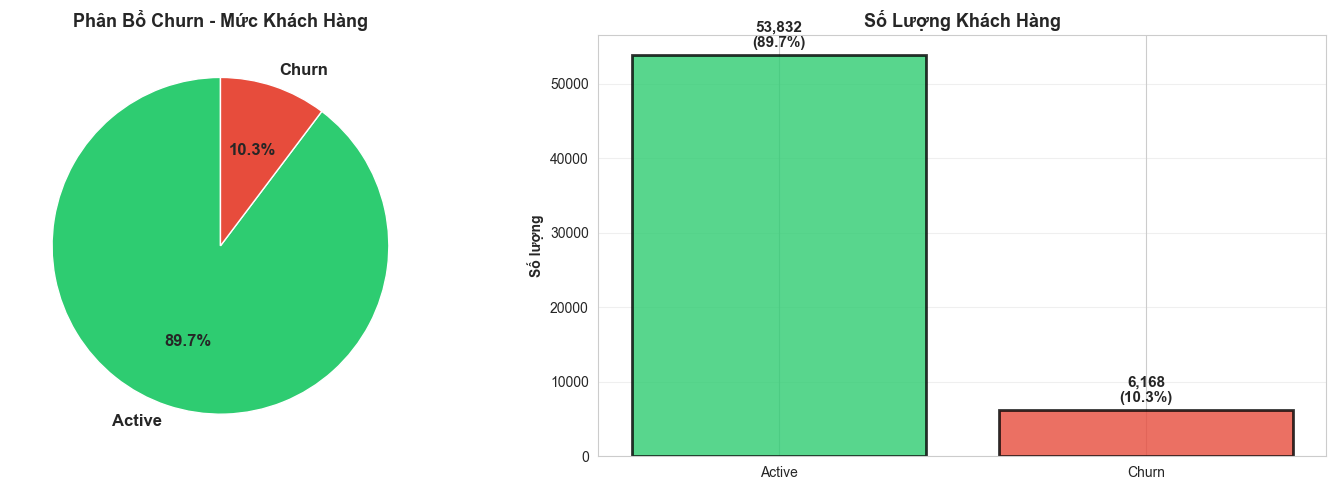


✅ Visualization completed!

MẪU DỮ LIỆU CHURN (CUSTOMER LEVEL)
   customer_id  churn_label
0            1            0
1            2            0
2            3            0
3            4            0
4            5            0
5            6            0
6            7            0
7            8            0
8            9            1
9           10            1


In [4]:
# ==================================================
# VISUALIZATION - CHURN DISTRIBUTION
# ==================================================
print("\n" + "="*70)
print("VISUALIZATION - PHÂN BỐ CHURN")
print("="*70)

# STEP 1: CUSTOMER-LEVEL CHURN (từ df_customer_churn)
# ==================================================
print(f"\n✓ Customer-level churn distribution:")
print(f"  - Total customers: {len(df_customer_churn):,}")
print(f"  - Churned customers: {(df_customer_churn['is_churn'] == 1).sum():,} ({(df_customer_churn['is_churn'] == 1).sum()/len(df_customer_churn)*100:.1f}%)")
print(f"  - Active customers: {(df_customer_churn['is_churn'] == 0).sum():,} ({(df_customer_churn['is_churn'] == 0).sum()/len(df_customer_churn)*100:.1f}%)")

# STEP 2: VISUALIZATION (CHARTS 2 & 3)
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Customer-level Churn Distribution (Pie)
churn_dist = df_customer_churn['is_churn'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels_pie = ['Active', 'Churn']
wedges, texts, autotexts = axes[0].pie(
    churn_dist.values, 
    labels=labels_pie, 
    autopct='%1.1f%%', 
    colors=colors[:len(churn_dist)], 
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title('Phân Bổ Churn - Mức Khách Hàng', fontweight='bold', fontsize=13)

# Chart 2: Customer-level Churn Distribution (Bar)
axes[1].bar(
    labels_pie[:len(churn_dist)], 
    churn_dist.values, 
    color=colors[:len(churn_dist)], 
    edgecolor='black', 
    linewidth=2,
    alpha=0.8
)
axes[1].set_title('Số Lượng Khách Hàng', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Số lượng', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_dist.values):
    axes[1].text(i, v + max(churn_dist.values)*0.02, f'{v:,}\n({v/churn_dist.sum()*100:.1f}%)', 
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Visualization completed!")

# ==================================================
# SUMMARY TABLE
# ==================================================
print("\n" + "="*70)
print("MẪU DỮ LIỆU CHURN (CUSTOMER LEVEL)")
print("="*70)
summary_customer = df_customer_churn[['customer_id', 'is_churn']].copy()
summary_customer.columns = ['customer_id', 'churn_label']
print(summary_customer.head(10))


---
## Phần 4: Feature Engineering

In [4]:
# ==================================================
# PHẦN 4: FEATURE ENGINEERING
# ==================================================
# Dựa trên logic từ feature_engineering_ver2.py

print("="*70)
print("PHẦN 4: FEATURE ENGINEERING")
print("="*70)

AS_OF_DATE_FE = pd.Timestamp("2025-12-31")

# ==================================================
# 4.1 - RECENCY & ACTIVITY FEATURES (ACCOUNT LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.1 RECENCY & ACTIVITY FEATURES")
print("-"*70)

df_transactions['transaction_datetime'] = pd.to_datetime(df_transactions['transaction_datetime'])
df_transactions = df_transactions.sort_values("transaction_datetime")

# Last transaction date
last_txn = (
    df_transactions.groupby("account_id")["transaction_datetime"]
    .max()
    .reset_index()
)

last_txn["days_since_last_txn"] = (
    AS_OF_DATE_FE - last_txn["transaction_datetime"]
).dt.days

# Transaction count by period
txn_tmp = df_transactions.copy()
txn_tmp["days_diff"] = (AS_OF_DATE_FE - txn_tmp["transaction_datetime"]).dt.days

txn_features = last_txn[["account_id", "days_since_last_txn"]]

for m in [1, 3, 6]:
    txn_features[f"txn_count_{m}m"] = (
        txn_tmp[txn_tmp["days_diff"] <= m * 30]
        .groupby("account_id")
        .size()
    )

txn_features = txn_features.fillna(0).reset_index(drop=True)
print(f"✅ Recency & Activity: 4 features created")

# ==================================================
# 4.2 - BALANCE LEVEL FEATURES (ACCOUNT LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.2 BALANCE LEVEL FEATURES (3 MONTHS)")
print("-"*70)

df_balance_snapshots['snapshot_date'] = pd.to_datetime(df_balance_snapshots['snapshot_date'])

balances_3m = df_balance_snapshots[
    df_balance_snapshots["snapshot_date"] >= AS_OF_DATE_FE - pd.DateOffset(months=3)
]

balance_level = (
    balances_3m.groupby("account_id")["balance"]
    .agg(
        avg_balance_3m="mean",
        min_balance_3m="min",
        std_balance_3m="std"
    )
    .reset_index()
)

balance_level["std_balance_3m"] = balance_level["std_balance_3m"].fillna(0)
print(f"✅ Balance Level: 3 features created")

# ==================================================
# 4.3 - BALANCE DYNAMICS FEATURES (ACCOUNT LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.3 BALANCE DYNAMICS FEATURES (3 MONTHS)")
print("-"*70)

balance_dyn = (
    balances_3m.sort_values("snapshot_date")
    .groupby("account_id")
    .agg(
        first_balance=("balance", "first"),
        last_balance=("balance", "last")
    )
    .reset_index()
)

balance_dyn["balance_drop_3m"] = (
    balance_dyn["last_balance"] - balance_dyn["first_balance"]
) / balance_dyn["first_balance"].replace(0, np.nan)

balance_dyn["balance_drop_3m"] = balance_dyn["balance_drop_3m"].fillna(0)
balance_dyn = balance_dyn[["account_id", "balance_drop_3m"]]
print(f"✅ Balance Dynamics: 1 feature created")

# ==================================================
# 4.4 - CASA MIGRATION FEATURES (ACCOUNT LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.4 CASA MIGRATION FEATURES (3 MONTHS)")
print("-"*70)

txns_3m = df_transactions[
    df_transactions["transaction_datetime"] >= AS_OF_DATE_FE - pd.DateOffset(months=3)
]

inflow = (
    txns_3m[txns_3m["amount"] > 0]
    .groupby("account_id")["amount"]
    .sum()
)

term_transfer = (
    txns_3m[txns_3m["transaction_type"] == "TRANSFER_TO_TERM"]
    .groupby("account_id")["amount"]
    .sum()
)

migration = pd.DataFrame({
    "account_id": inflow.index,
    "transfer_to_term_ratio_3m": (term_transfer / inflow).fillna(0)
}).reset_index(drop=True)

print(f"✅ CASA Migration: 1 feature created")

# ==================================================
# 4.5 - CREDIT CARD FEATURES (CUSTOMER LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.5 CREDIT CARD FEATURES")
print("-"*70)

cc_features = df_credit_cards.copy()

cc_features["has_credit_card"] = cc_features["has_credit_card"].astype(int)
cc_features["cc_active_flag"] = (cc_features["card_status"] == "ACTIVE").astype(int)
cc_features["delinquency_days"] = cc_features["delinquency_days"].fillna(0)

cc_features = cc_features[
    ["customer_id", "has_credit_card", "cc_active_flag", "delinquency_days"]
].copy()

print(f"✅ Credit Card: 3 features created")

# ==================================================
# 4.6 - CUSTOMER PROFILE FEATURES (CUSTOMER LEVEL)
# ==================================================
print("\n" + "-"*70)
print("4.6 CUSTOMER PROFILE FEATURES")
print("-"*70)

cust_features = df_customer.copy()

cust_features['join_date'] = pd.to_datetime(cust_features['join_date'])
cust_features["tenure_days"] = (AS_OF_DATE_FE - cust_features["join_date"]).dt.days

# Age - try multiple approaches
if "age" in cust_features.columns:
    cust_features["age_feat"] = cust_features["age"]
elif "date_of_birth" in cust_features.columns:
    cust_features['date_of_birth'] = pd.to_datetime(cust_features['date_of_birth'])
    cust_features["age_feat"] = (AS_OF_DATE_FE.year - cust_features["date_of_birth"].dt.year)
else:
    cust_features["age_feat"] = 0

# Keep safe columns only
cust_features = cust_features[
    ["customer_id", "age_feat", "tenure_days"]
].copy()

print(f"✅ Customer Profile: 2 features created (age_feat, tenure_days)")

# ==================================================
# 4.7 - MERGE ALL FEATURES & CHURN LABEL
# ==================================================
print("\n" + "="*70)
print("4.7 MERGE ALL FEATURES & CHURN LABEL")
print("="*70)

# Start from account level features
df_features = (
    df_account[["account_id", "customer_id"]]
    .merge(txn_features, on="account_id", how="left")
    .merge(balance_level, on="account_id", how="left")
    .merge(balance_dyn, on="account_id", how="left")
    .merge(migration, on="account_id", how="left")
)

# Add customer-level features
df_features = df_features.merge(cc_features, on="customer_id", how="left")
df_features = df_features.merge(cust_features, on="customer_id", how="left")

# Add churn label (from PHẦN 3)
df_features = df_features.merge(
    df_customer_churn[["customer_id", "is_churn"]], 
    on="customer_id", 
    how="left"
)

# Fill missing values
df_features = df_features.fillna(0)

# Get feature columns
feature_cols = [col for col in df_features.columns if col not in ['account_id', 'customer_id', 'is_churn']]

print(f"\n✅ Merge Completed!")
print(f"   - Total Features: {len(feature_cols)}")
print(f"   - Dataset Shape: {df_features.shape[0]:,} rows × {df_features.shape[1]} columns")

# ==================================================
# 4.8 - SUMMARY & STATISTICS
# ==================================================
print("\n" + "="*70)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\n✅ FEATURE CATEGORIES:")
print(f"   - Recency & Activity: 4 features")
print(f"   - Balance Level: 3 features")
print(f"   - Balance Dynamics: 1 feature")
print(f"   - CASA Migration: 1 feature")
print(f"   - Credit Card: 3 features")
print(f"   - Customer Profile: 2 features")
print(f"   - TOTAL: {len(feature_cols)} features")

print(f"\n✅ DATA QUALITY:")
print(f"   - Rows (accounts): {df_features.shape[0]:,}")
print(f"   - Columns (features + target): {df_features.shape[1]}")
print(f"   - Missing values: {df_features.isnull().sum().sum()}")

print(f"\n✅ TARGET VARIABLE (CHURN - ACCOUNT LEVEL):")
churn_dist = df_features['is_churn'].value_counts()
for label, count in churn_dist.items():
    pct = count / len(df_features) * 100
    status = 'Churn' if label == 1 else 'Active'
    print(f"   - {status}: {count:,} ({pct:.2f}%)")

print(f"\n📋 FEATURE LIST:")
for i, col in enumerate(feature_cols, 1):
    dtype = df_features[col].dtype
    print(f"   {i:2d}. {col:35s} ({dtype})")

print(f"\n✅ Sample Data (first 5 rows):")
print(df_features.head())

print("\n" + "="*70)


PHẦN 4: FEATURE ENGINEERING

----------------------------------------------------------------------
4.1 RECENCY & ACTIVITY FEATURES
----------------------------------------------------------------------
✅ Recency & Activity: 4 features created

----------------------------------------------------------------------
4.2 BALANCE LEVEL FEATURES (3 MONTHS)
----------------------------------------------------------------------
✅ Balance Level: 3 features created

----------------------------------------------------------------------
4.3 BALANCE DYNAMICS FEATURES (3 MONTHS)
----------------------------------------------------------------------
✅ Balance Dynamics: 1 feature created

----------------------------------------------------------------------
4.4 CASA MIGRATION FEATURES (3 MONTHS)
----------------------------------------------------------------------
✅ CASA Migration: 1 feature created

----------------------------------------------------------------------
4.5 CREDIT CARD FEATURES
--

---
## Phần 5: Train / Test split 


In [5]:
# ==================================================
# PHẦN 5: STRATIFIED TRAIN/TEST SPLIT
# ==================================================
print("="*70)
print("PHẦN 9: STRATIFIED TRAIN/TEST SPLIT (80/20)")
print("="*70)

from sklearn.model_selection import train_test_split

# ==================================================
# 5.1 - PREPARE FEATURES & TARGET
# ==================================================
print("\n" + "-"*70)
print("5.1 PREPARE FEATURES & TARGET")
print("-"*70)

X = df_features[feature_cols].copy()
y = df_features['is_churn'].copy()

print(f"✅ Features prepared: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"✓ Target variable: {y.name}")
print(f"✓ Churn distribution: {y.value_counts().to_dict()}")

# ==================================================
# 5.2 - STRATIFIED SPLIT (80/20)
# ==================================================
print("\n" + "-"*70)
print("5.2 STRATIFIED SPLIT (80/20)")
print("-"*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"\n✅ Train/Test Split Completed:")
print(f"   - Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   - Test:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n✓ Churn Rate Distribution:")
print(f"   - Train: {y_train.mean()*100:.2f}%")
print(f"   - Test:  {y_test.mean()*100:.2f}%")

print("\n" + "="*70)


PHẦN 9: STRATIFIED TRAIN/TEST SPLIT (80/20)

----------------------------------------------------------------------
5.1 PREPARE FEATURES & TARGET
----------------------------------------------------------------------
✅ Features prepared: 60,000 rows × 14 features
✓ Target variable: is_churn
✓ Churn distribution: {0: 53832, 1: 6168}

----------------------------------------------------------------------
5.2 STRATIFIED SPLIT (80/20)
----------------------------------------------------------------------

✅ Train/Test Split Completed:
   - Train: 48,000 rows (80.0%)
   - Test:  12,000 rows (20.0%)

✓ Churn Rate Distribution:
   - Train: 10.28%
   - Test:  10.28%



# PHẦN 6: MODEL TRAINING

LOGISTIC REGRESSION

----------------------------------------------------------------------
SETUP & EVALUATION FUNCTION
----------------------------------------------------------------------
✅ Evaluation function defined

----------------------------------------------------------------------
 TRAIN LOGISTIC REGRESSION BASELINE
----------------------------------------------------------------------

✅ LogisticRegression trained:
                         auc  accuracy  precision    recall        f1
model                                                                
LogisticRegression  0.865689  0.734708   0.271341  0.937981  0.420919

----------------------------------------------------------------------
CONFUSION MATRIX - LOGISTIC REGRESSION
----------------------------------------------------------------------


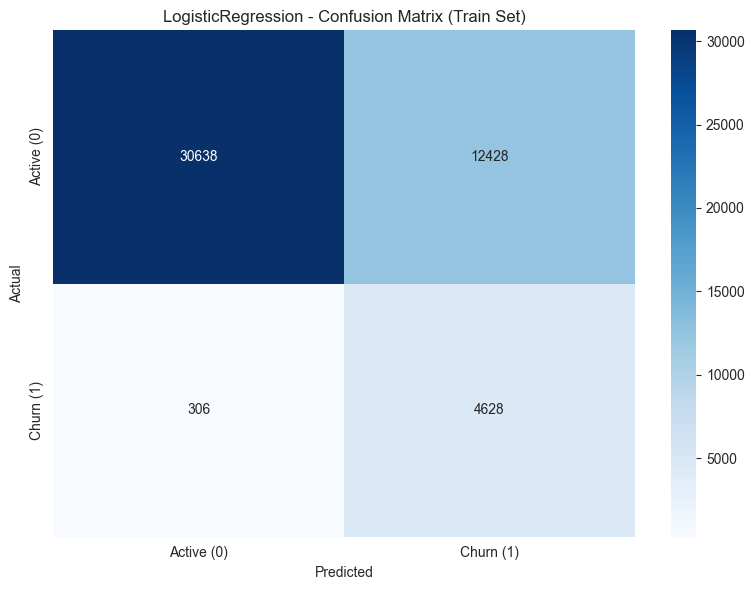

In [6]:
# ==================================================
# LOGISTIC REGRESSION
# ==================================================
print("="*70)
print("LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# - SETUP & DEFINE EVALUATION FUNCTION
# ==================================================
print("\n" + "-"*70)
print("SETUP & EVALUATION FUNCTION")
print("-"*70)

results = []

def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model and evaluate on test set"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    # Get probabilities for AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te) if hasattr(model, 'decision_function') else np.zeros(len(y_te))
    
    return {
        'model': name,
        'auc': float(roc_auc_score(y_te, y_proba)),
        'accuracy': float(accuracy_score(y_te, y_pred)),
        'precision': float(precision_score(y_te, y_pred, zero_division=0)),
        'recall': float(recall_score(y_te, y_pred, zero_division=0)),
        'f1': float(f1_score(y_te, y_pred, zero_division=0))
    }

print("✅ Evaluation function defined")

# ==================================================
# - TRAIN LOGISTIC REGRESSION
# ==================================================
print("\n" + "-"*70)
print(" TRAIN LOGISTIC REGRESSION BASELINE")
print("-"*70)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42)
results.append(eval_model('LogisticRegression', logreg, X_train, y_train, X_train, y_train))

results_df = pd.DataFrame(results).set_index('model')
print("\n✅ LogisticRegression trained:")
print(results_df.to_string())

# ==================================================
#  CONFUSION MATRIX VISUALIZATION
# ==================================================
print("\n" + "-"*70)
print("CONFUSION MATRIX - LOGISTIC REGRESSION")
print("-"*70)

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_train)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LogisticRegression - Confusion Matrix (Train Set)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)



In [7]:
# === Tree-based and Boosting models ===
print('\n' + '='*70)
print(' RandomForest, XGBoost')
print('='*70)

from sklearn.ensemble import RandomForestClassifier

models = {}
results = []

# Helper evaluation
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:,1]
    else:
        y_proba = model.decision_function(X_te) if hasattr(model, 'decision_function') else np.zeros(len(y_te))
    return {
        'model': name,
        'auc': float(roc_auc_score(y_te, y_proba)),
        'accuracy': float(accuracy_score(y_te, y_pred)),
        'precision': float(precision_score(y_te, y_pred, zero_division=0)),
        'recall': float(recall_score(y_te, y_pred, zero_division=0)),
        'f1': float(f1_score(y_te, y_pred, zero_division=0))
    }
# Random Forest
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=42)
models['RandomForest'] = rf
results.append(eval_model('RandomForest', rf, X_train, y_train, X_train, y_train))

# Try XGBoost
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
    models['XGBoost'] = xgb
    results.append(eval_model('XGBoost', xgb, X_train, y_train, X_train, y_train))
except Exception as e:
    print('XGBoost not available or failed to run:', e)

results_df = pd.DataFrame(results).set_index('model')
print('\nBaseline results on train set:')
print(results_df)





 RandomForest, XGBoost

Baseline results on train set:
                   auc  accuracy  precision    recall        f1
model                                                          
RandomForest  1.000000  1.000000     1.0000  1.000000  1.000000
XGBoost       0.999904  0.996979     0.9973  0.973247  0.985127



 Confusion Matrix - RandomForest & XGBoost


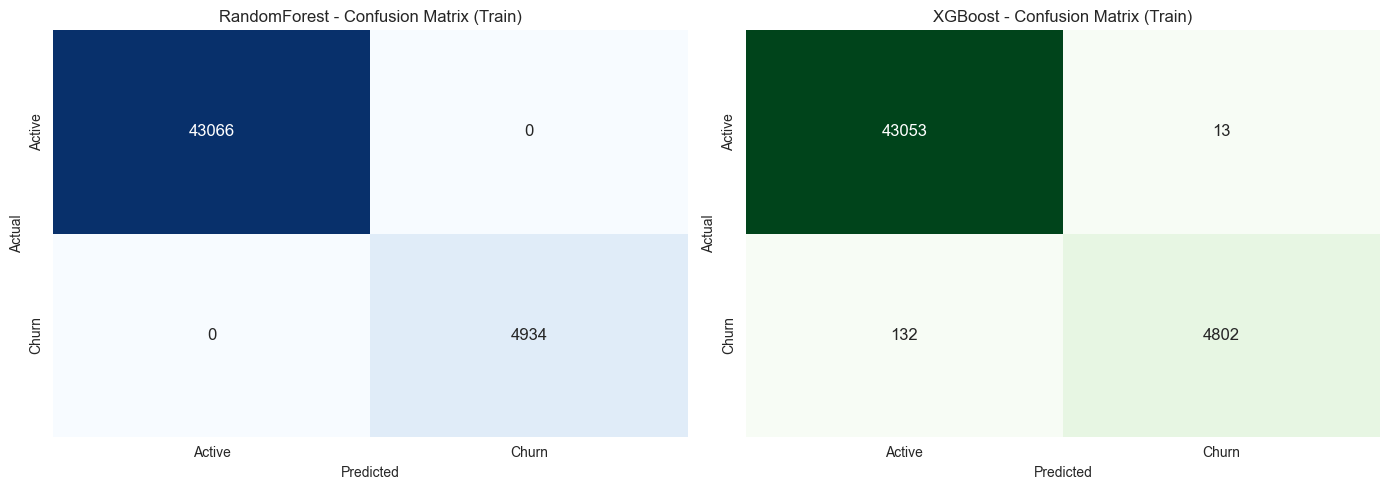

In [8]:
# === Confusion Matrix cho RandomForest và XGBoost ===
print('\n' + '='*70)
print(' Confusion Matrix - RandomForest & XGBoost')
print('='*70)

# Ensure models exist; if not, train them
try:
    rf
except NameError:
    rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)

# XGBoost may not be available in some environments
xgb_available = 'xgb' in globals()
if xgb_available:
    try:
        xgb
    except NameError:
        from xgboost import XGBClassifier
        xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
        xgb.fit(X_train, y_train)

# Predictions
y_rf_pred = rf.predict(X_train)
cm_rf = confusion_matrix(y_train, y_rf_pred)

if xgb_available:
    y_xgb_pred = xgb.predict(X_train)
    cm_xgb = confusion_matrix(y_train, y_xgb_pred)

# Plot side-by-side
n_plots = 2 if xgb_available else 1
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
if n_plots == 1:
    axes = [axes]

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churn'], yticklabels=['Active','Churn'],
            ax=axes[0], cbar=False, annot_kws={'size':12})
axes[0].set_title('RandomForest - Confusion Matrix (Train)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

if xgb_available:
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Active','Churn'], yticklabels=['Active','Churn'],
                ax=axes[1], cbar=False, annot_kws={'size':12})
    axes[1].set_title('XGBoost - Confusion Matrix (Train)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()






# PHẦN 7 : Hyperparameter Tuning


Tìm ngưỡng tối ưu: LogisticRegression & XGBoost & RandomForest

LogisticRegression - Best threshold (by F1): 0.57
  F1: 0.4449, Precision: 0.3213, Recall: 0.7229, Accuracy: 0.8145


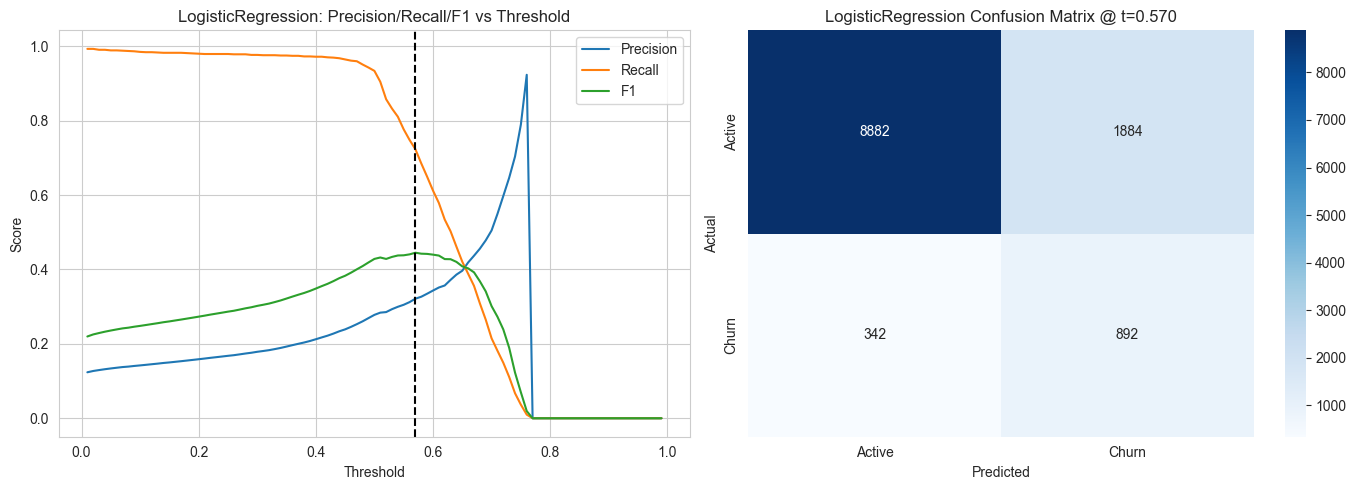


XGBoost - Best threshold (by F1): 0.53
  F1: 0.9339, Precision: 0.9590, Recall: 0.9100, Accuracy: 0.9868


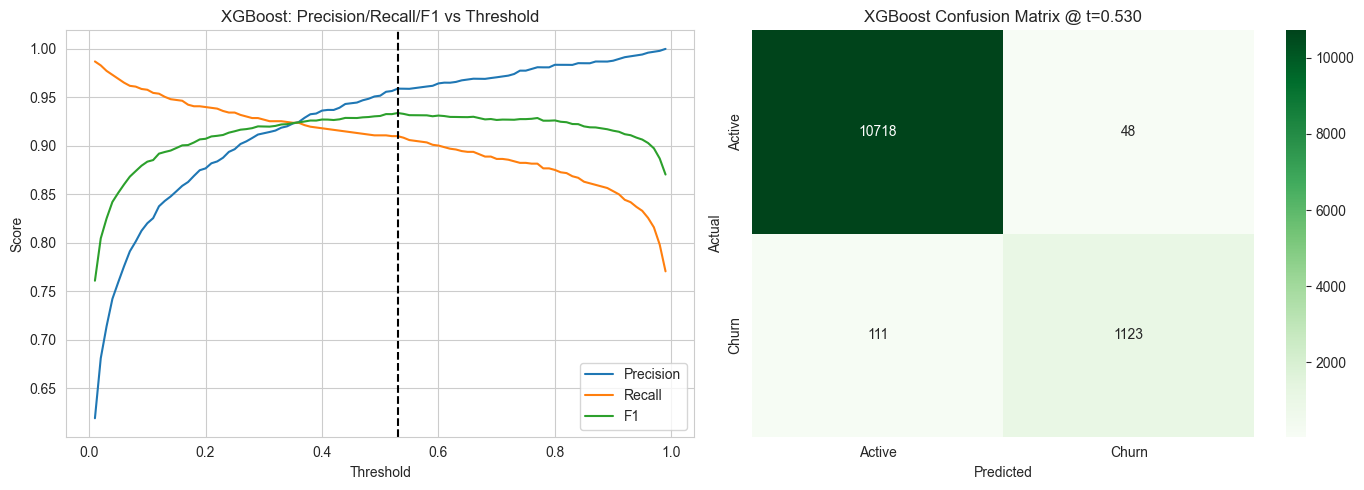

In [9]:
# === Tìm ngưỡng tối ưu cho LogisticRegression và XGBoost và RandomForest===
print('\n' + '='*70)
print('Tìm ngưỡng tối ưu: LogisticRegression & XGBoost & RandomForest')
print('='*70)

def find_optimal_thresholds(y_true, y_proba, thresholds=np.linspace(0.01, 0.99, 99)):
    scores = {'threshold': [], 'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        p = precision_score(y_true, y_pred_t, zero_division=0)
        r = recall_score(y_true, y_pred_t, zero_division=0)
        f = f1_score(y_true, y_pred_t, zero_division=0)
        acc = (y_pred_t == y_true).mean()
        scores['threshold'].append(t)
        scores['precision'].append(p)
        scores['recall'].append(r)
        scores['f1'].append(f)
        scores['accuracy'].append(acc)
    # choose threshold maximizing F1
    best_idx = int(np.argmax(scores['f1']))
    best = {k: scores[k][best_idx] for k in ['threshold','precision','recall','f1','accuracy']}
    return scores, best

# --- LogisticRegression ---
logreg_model = None
if 'logreg_final' in globals():
    logreg_model = logreg_final
elif 'logreg' in globals():
    logreg_model = logreg
if logreg_model is not None:
    try:
        y_logreg_proba = logreg_model.predict_proba(X_test)[:, 1]
        scores_logreg, best_logreg = find_optimal_thresholds(y_test, y_logreg_proba)
        print('\nLogisticRegression - Best threshold (by F1):', round(best_logreg['threshold'], 3))
        print(f"  F1: {best_logreg['f1']:.4f}, Precision: {best_logreg['precision']:.4f}, Recall: {best_logreg['recall']:.4f}, Accuracy: {best_logreg['accuracy']:.4f}")

        # plot metrics vs threshold
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        ax[0].plot(scores_logreg['threshold'], scores_logreg['precision'], label='Precision')
        ax[0].plot(scores_logreg['threshold'], scores_logreg['recall'], label='Recall')
        ax[0].plot(scores_logreg['threshold'], scores_logreg['f1'], label='F1')
        ax[0].axvline(best_logreg['threshold'], color='k', linestyle='--')
        ax[0].set_xlabel('Threshold')
        ax[0].set_ylabel('Score')
        ax[0].set_title('LogisticRegression: Precision/Recall/F1 vs Threshold')
        ax[0].legend()

        # confusion matrix at best threshold
        y_logreg_best = (y_logreg_proba >= best_logreg['threshold']).astype(int)
        cm_logreg = confusion_matrix(y_test, y_logreg_best)
        sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=ax[1], xticklabels=['Active','Churn'], yticklabels=['Active','Churn'])
        ax[1].set_title(f'LogisticRegression Confusion Matrix @ t={best_logreg["threshold"]:.3f}')
        ax[1].set_xlabel('Predicted')
        ax[1].set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print('Lỗi khi tính ngưỡng tối ưu cho LogisticRegression:', e)

else:
    print('LogisticRegression model not found in workspace. Run training cell first.')


# --- XGBoost ---
if 'xgb' in globals():
    try:
        y_xgb_proba = xgb.predict_proba(X_test)[:, 1]
        scores_xgb, best_xgb = find_optimal_thresholds(y_test, y_xgb_proba)
        print('\nXGBoost - Best threshold (by F1):', round(best_xgb['threshold'], 3))
        print(f"  F1: {best_xgb['f1']:.4f}, Precision: {best_xgb['precision']:.4f}, Recall: {best_xgb['recall']:.4f}, Accuracy: {best_xgb['accuracy']:.4f}")

        # plot metrics vs threshol
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        ax[0].plot(scores_xgb['threshold'], scores_xgb['precision'], label='Precision')
        ax[0].plot(scores_xgb['threshold'], scores_xgb['recall'], label='Recall')
        ax[0].plot(scores_xgb['threshold'], scores_xgb['f1'], label='F1')
        ax[0].axvline(best_xgb['threshold'], color='k', linestyle='--')
        ax[0].set_xlabel('Threshold')
        ax[0].set_ylabel('Score')
        ax[0].set_title('XGBoost: Precision/Recall/F1 vs Threshold')
        ax[0].legend()

        # confusion matrix at best threshold
        y_xgb_best = (y_xgb_proba >= best_xgb['threshold']).astype(int)
        cm_xgb = confusion_matrix(y_test, y_xgb_best)
        sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax[1], xticklabels=['Active','Churn'], yticklabels=['Active','Churn'])
        ax[1].set_title(f'XGBoost Confusion Matrix @ t={best_xgb["threshold"]:.3f}')
        ax[1].set_xlabel('Predicted')
        ax[1].set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print('XGBoost present but failed to compute thresholds:', e)

else:
    print('\nXGBoost model not available; skipped threshold search for XGBoost.')


In [10]:
# === Test Predictions & Comprehensive Model Evaluation ===
print('\n' + '='*70)
print(' DỰ ĐOÁN TRÊN TẬP TEST & TỔNG HỢP CHỈ SỐ')
print('='*70)
# Ensure all trained models exist
models_to_test = {}
if 'logreg_final' in globals():
    models_to_test['LogisticRegression'] = logreg_final
elif 'logreg' in globals():
    models_to_test['LogisticRegression'] = logreg
    
if 'rf' in globals():
    models_to_test['RandomForest'] = rf
    
if 'xgb' in globals():
    models_to_test['XGBoost'] = xgb

print(f"\n✅ Mô hình sẵn sàng: {list(models_to_test.keys())}")

# Define optimal thresholds from threshold tuning phase
optimal_thresholds = {
    'LogisticRegression': 0.57,
    'RandomForest': 0.5,
    'XGBoost': 0.53
}

# Make predictions on test set with optimal thresholds
test_results = {}

for model_name, model in models_to_test.items():
    print(f"\n📊 {model_name}:")
    
    # Get probabilities
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Apply optimal threshold
    optimal_threshold = optimal_thresholds.get(model_name, 0.5)
    y_pred = (y_proba >= optimal_threshold).astype(int) if y_proba is not None else model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Store results
    test_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'specificity': specificity,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'threshold': optimal_threshold
    }
    
    # Print metrics with threshold information
    print(f"  ├─ Threshold:  {optimal_threshold:.2f}")
    print(f"  ├─ Accuracy:   {accuracy:.4f}")
    print(f"  ├─ Precision:  {precision:.4f}")
    print(f"  ├─ Recall:     {recall:.4f}")
    print(f"  ├─ F1-Score:   {f1:.4f}")
    print(f"  ├─ AUC-ROC:    {auc_roc:.4f}")
    print(f"  └─ Specificity: {specificity:.4f}")
    print(f"     Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Create summary DataFrame
summary_data = []
for model_name, metrics in test_results.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'AUC-ROC': f"{metrics['auc_roc']:.4f}",
        'Specificity': f"{metrics['specificity']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)

print("="*70)
print(summary_df.to_string(index=False))



 DỰ ĐOÁN TRÊN TẬP TEST & TỔNG HỢP CHỈ SỐ

✅ Mô hình sẵn sàng: ['LogisticRegression', 'RandomForest', 'XGBoost']

📊 LogisticRegression:
  ├─ Threshold:  0.57
  ├─ Accuracy:   0.8145
  ├─ Precision:  0.3213
  ├─ Recall:     0.7229
  ├─ F1-Score:   0.4449
  ├─ AUC-ROC:    0.8723
  └─ Specificity: 0.8250
     Confusion Matrix: TN=8882, FP=1884, FN=342, TP=892

📊 RandomForest:
  ├─ Threshold:  0.50
  ├─ Accuracy:   0.9874
  ├─ Precision:  0.9680
  ├─ Recall:     0.9076
  ├─ F1-Score:   0.9368
  ├─ AUC-ROC:    0.9944
  └─ Specificity: 0.9966
     Confusion Matrix: TN=10729, FP=37, FN=114, TP=1120

📊 XGBoost:
  ├─ Threshold:  0.53
  ├─ Accuracy:   0.9868
  ├─ Precision:  0.9590
  ├─ Recall:     0.9100
  ├─ F1-Score:   0.9339
  ├─ AUC-ROC:    0.9961
  └─ Specificity: 0.9955
     Confusion Matrix: TN=10718, FP=48, FN=111, TP=1123
             Model Accuracy Precision Recall F1-Score AUC-ROC Specificity
LogisticRegression   0.8145    0.3213 0.7229   0.4449  0.8723      0.8250
      RandomForest


CONFUSION MATRIX CHO TẤT CẢ CÁC MÔ HÌNH (TEST SET)


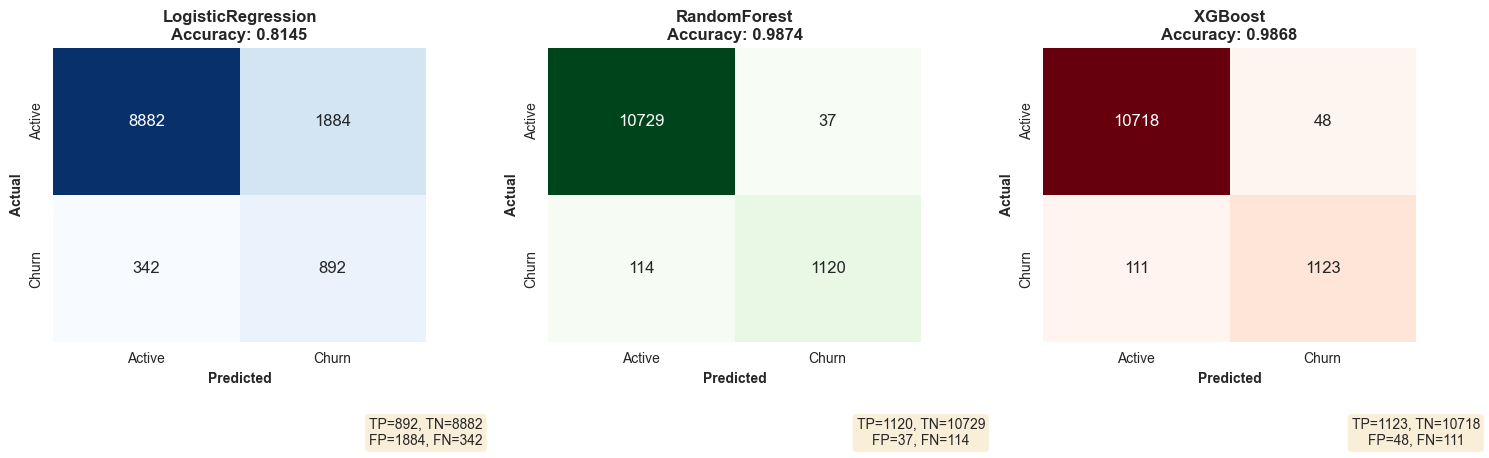


✅ Confusion Matrix plotted for all models on test set!


In [16]:
# === Confusion Matrix cho tất cả các mô hình ===
print('\n' + '='*70)
print('CONFUSION MATRIX CHO TẤT CẢ CÁC MÔ HÌNH (TEST SET)')
print('='*70)

# Create 1x3 subplots for confusion matrices
n_models = len(test_results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
if n_models == 1:
    axes = [axes]

colors_map = ['Blues', 'Greens', 'Reds']
model_list = list(test_results.keys())

for idx, (model_name, metrics) in enumerate(test_results.items()):
    cm = metrics['confusion_matrix']
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors_map[idx],
                xticklabels=['Active', 'Churn'], 
                yticklabels=['Active', 'Churn'],
                ax=axes[idx], cbar=False, annot_kws={'size': 12})
    
    # Add labels and title
    axes[idx].set_xlabel('Predicted', fontweight='bold')
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_title(f'{model_name}\nAccuracy: {metrics["accuracy"]:.4f}', 
                       fontweight='bold', fontsize=12)
    
    # Add values below matrix
    tn, fp, fn, tp = cm.ravel()
    text_str = f'TP={tp}, TN={tn}\nFP={fp}, FN={fn}'
    axes[idx].text(1, -0.35, text_str, ha='center', transform=axes[idx].transAxes,
                  fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✅ Confusion Matrix plotted for all models on test set!")



FEATURE IMPORTANCES - PHÂN TÍCH CÁC FEATURES QUAN TRỌNG

----------------------------------------------------------------------
LOGISTIC REGRESSION - FEATURE COEFFICIENTS
----------------------------------------------------------------------

✅ Top 10 Features (by absolute coefficient):
            Feature   Coefficient
        tenure_days  2.917538e-04
days_since_last_txn  1.952441e-05
           age_feat  9.161997e-06
   delinquency_days  2.484573e-06
     avg_balance_3m -6.861216e-07
     std_balance_3m  5.987748e-07
    balance_drop_3m -3.355484e-07
     min_balance_3m  2.525746e-07
    has_credit_card  1.053410e-07
     cc_active_flag  4.273521e-08


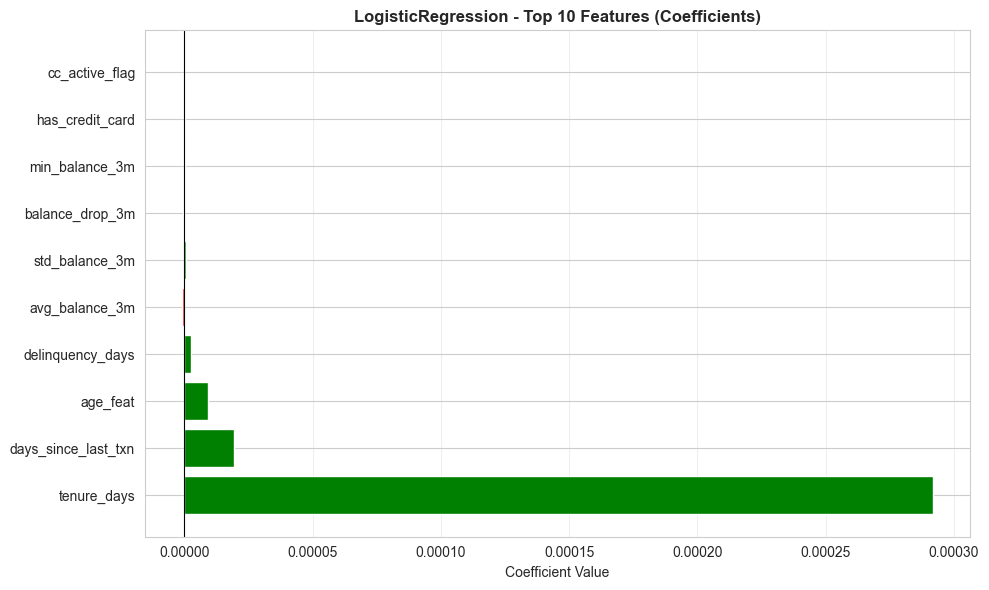


✓ Positive coefficient = increases churn probability (RED)
✓ Negative coefficient = decreases churn probability (GREEN)

----------------------------------------------------------------------
RANDOM FOREST - FEATURE IMPORTANCES
----------------------------------------------------------------------

✅ Top 10 Features (by importance):
                  Feature  Importance
           min_balance_3m    0.249646
          balance_drop_3m    0.208897
           avg_balance_3m    0.200890
           std_balance_3m    0.130651
transfer_to_term_ratio_3m    0.070678
      days_since_last_txn    0.038168
          has_credit_card    0.029876
           cc_active_flag    0.028777
         delinquency_days    0.016806
              tenure_days    0.013822


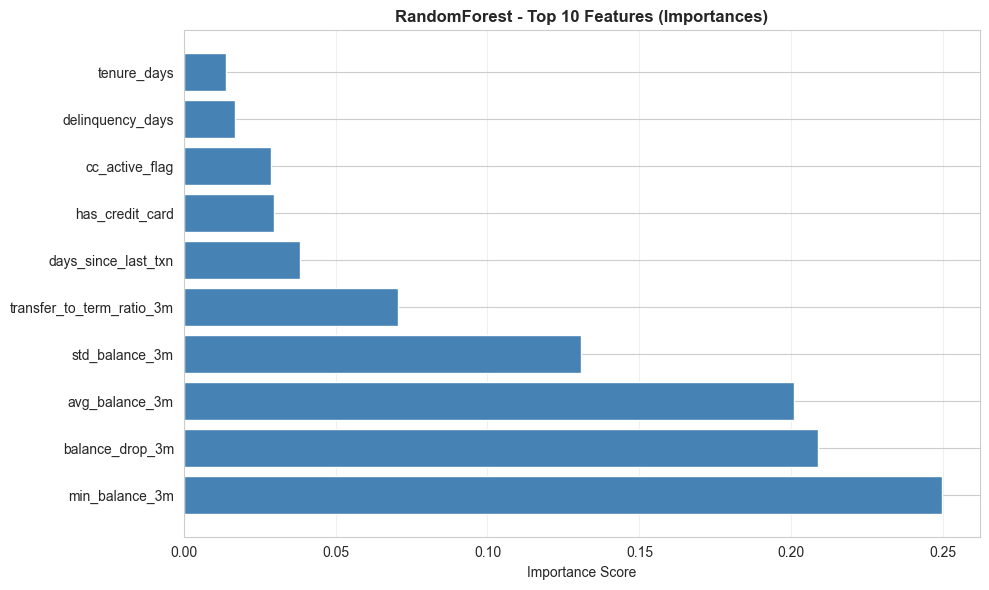


✓ Total importance sum: 1.0000

----------------------------------------------------------------------
XGBOOST - FEATURE IMPORTANCES
----------------------------------------------------------------------

✅ Top 10 Features (by importance):
                  Feature  Importance
           min_balance_3m    0.505889
         delinquency_days    0.140456
           cc_active_flag    0.138347
          balance_drop_3m    0.062428
           avg_balance_3m    0.053481
          has_credit_card    0.048252
transfer_to_term_ratio_3m    0.026806
      days_since_last_txn    0.009610
           std_balance_3m    0.005069
              tenure_days    0.004926


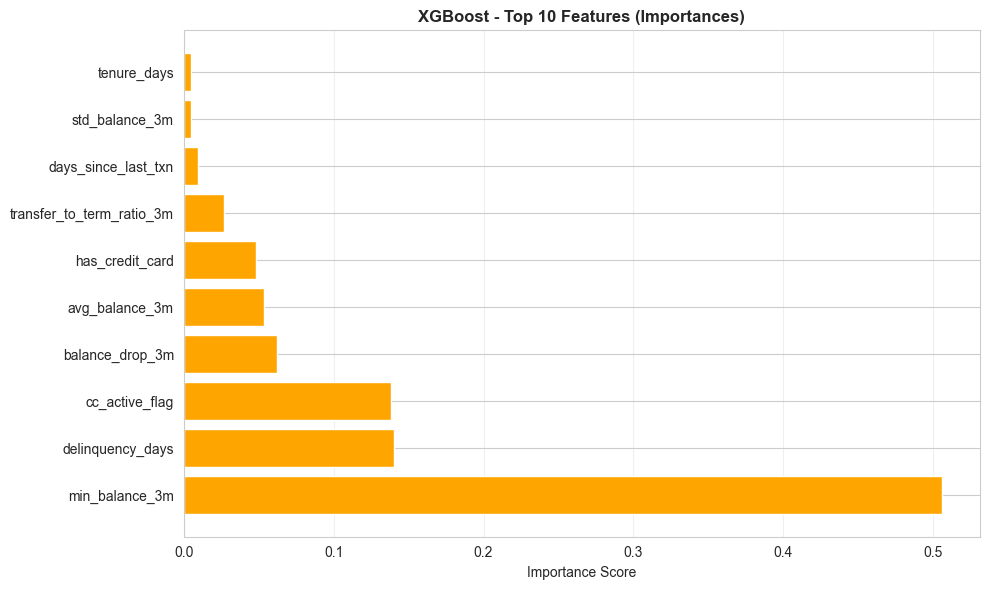


✓ Total importance sum: 1.0000


In [15]:
# ==================================================
# FEATURE IMPORTANCES - PHÂN TÍCH TÍNH QUAN TRỌNG CỦA FEATURES
# ==================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCES - PHÂN TÍCH CÁC FEATURES QUAN TRỌNG")
print("="*70)

# ==================================================
# LOGISTIC REGRESSION COEFFICIENTS
# ==================================================
print("\n" + "-"*70)
print("LOGISTIC REGRESSION - FEATURE COEFFICIENTS")
print("-"*70)

if 'logreg' in globals() and logreg is not None:
    try:
        # Get coefficients
        coefficients = pd.DataFrame({
            'Feature': feature_cols,
            'Coefficient': logreg.coef_[0]
        }).sort_values('Coefficient', key=abs, ascending=False)
        
        print("\n✅ Top 10 Features (by absolute coefficient):")
        print(coefficients.head(10).to_string(index=False))
        
        # Plot top features
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = coefficients.head(10)
        colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
        ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel('Coefficient Value')
        ax.set_title('LogisticRegression - Top 10 Features (Coefficients)', fontweight='bold', fontsize=12)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Positive coefficient = increases churn probability (RED)")
        print("✓ Negative coefficient = decreases churn probability (GREEN)")
    
    except Exception as e:
        print(f"Error plotting LogisticRegression coefficients: {e}")
else:
    print("LogisticRegression model not found in workspace.")

# ==================================================
# RANDOM FOREST FEATURE IMPORTANCES
# ==================================================
print("\n" + "-"*70)
print("RANDOM FOREST - FEATURE IMPORTANCES")
print("-"*70)

if 'rf' in globals() and rf is not None:
    try:
        # Get importances
        importances_rf = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\n✅ Top 10 Features (by importance):")
        print(importances_rf.head(10).to_string(index=False))
        
        # Plot top features
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = importances_rf.head(10)
        ax.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel('Importance Score')
        ax.set_title('RandomForest - Top 10 Features (Importances)', fontweight='bold', fontsize=12)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Total importance sum: {importances_rf['Importance'].sum():.4f}")
    
    except Exception as e:
        print(f"Error plotting RandomForest importances: {e}")
else:
    print("RandomForest model not found in workspace.")

# ==================================================
# XGBOOST FEATURE IMPORTANCES
# ==================================================
print("\n" + "-"*70)
print("XGBOOST - FEATURE IMPORTANCES")
print("-"*70)

if 'xgb' in globals() and xgb is not None:
    try:
        # Get importances
        importances_xgb = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': xgb.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\n✅ Top 10 Features (by importance):")
        print(importances_xgb.head(10).to_string(index=False))
        
        # Plot top features
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = importances_xgb.head(10)
        ax.barh(range(len(top_features)), top_features['Importance'], color='orange')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel('Importance Score')
        ax.set_title('XGBoost - Top 10 Features (Importances)', fontweight='bold', fontsize=12)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Total importance sum: {importances_xgb['Importance'].sum():.4f}")
    
    except Exception as e:
        print(f"Error plotting XGBoost importances: {e}")
else:
    print("XGBoost model not found in workspace.")



ĐÁNH GIÁ NGẮN GỌN - SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH

✅ Các mô hình sẵn sàng: ['LogisticRegression', 'RandomForest', 'XGBoost']

--------------------------------------------------------------------------------
BẢNG SO SÁNH HIỆU SUẤT
--------------------------------------------------------------------------------

🤖 LogisticRegression:
  Accuracy:   0.7437
  Precision:  0.2779
  Recall:     0.9335
  F1-Score:   0.4283
  AUC-ROC:    0.8723
  Specificity: 0.7219
  Confusion Matrix: TN=7772, FP=2994, FN=82, TP=1152

🤖 RandomForest:
  Accuracy:   0.9875
  Precision:  0.9689
  Recall:     0.9076
  F1-Score:   0.9372
  AUC-ROC:    0.9944
  Specificity: 0.9967
  Confusion Matrix: TN=10730, FP=36, FN=114, TP=1120

🤖 XGBoost:
  Accuracy:   0.9861
  Precision:  0.9517
  Recall:     0.9109
  F1-Score:   0.9308
  AUC-ROC:    0.9961
  Specificity: 0.9947
  Confusion Matrix: TN=10709, FP=57, FN=110, TP=1124

--------------------------------------------------------------------------------
BẢNG TÓM TẮT
-

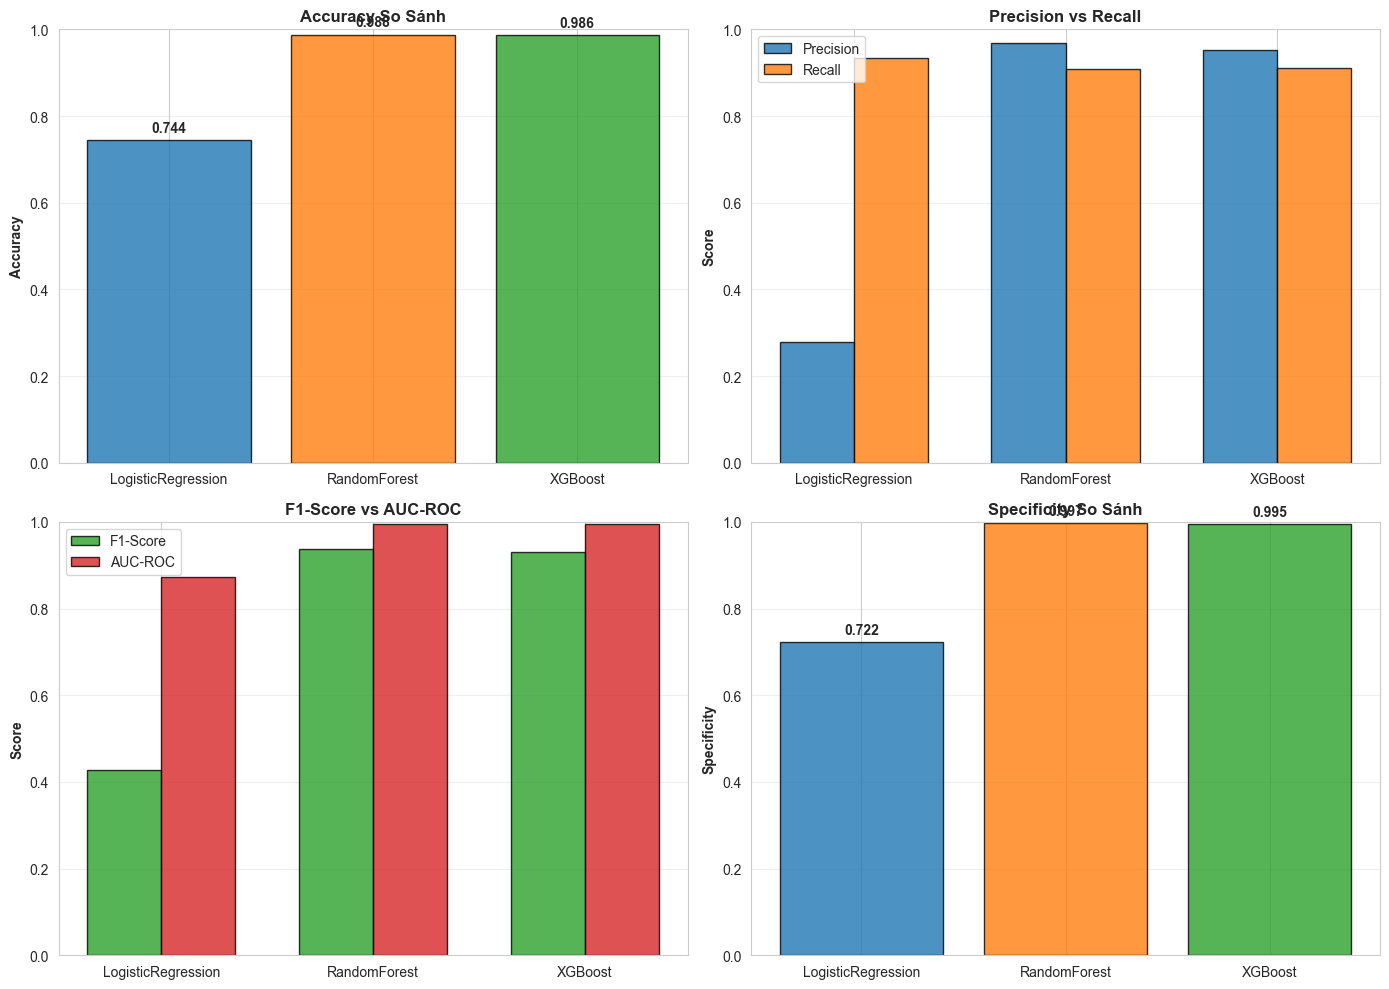


📊 TỔNG HỢP ĐÁNH GIÁ

🏆 MÔ HÌNH TỐT NHẤT (theo F1-Score): RandomForest
   F1-Score: 0.9372

   Hiệu suất chi tiết:
   ├─ Accuracy:   0.9875
   ├─ Precision:  0.9689
   ├─ Recall:     0.9076
   ├─ AUC-ROC:    0.9944
   └─ Specificity: 0.9967

🎯 MÔ HÌNH TỐT NHẤT (theo AUC-ROC): XGBoost
   AUC-ROC: 0.9961

✨ MÔ HÌNH TỐT NHẤT (theo Accuracy): RandomForest
   Accuracy: 0.9875

✅ ĐÃ HOÀN THÀNH ĐÁNH GIÁ


In [14]:
print('\n' + '='*80)
print('ĐÁNH GIÁ NGẮN GỌN - SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH')
print('='*80)

# Kiểm tra các mô hình có sẵn
models_available = {}
if 'logreg' in dir():
    models_available['LogisticRegression'] = logreg
if 'rf' in dir():
    models_available['RandomForest'] = rf
if 'xgb' in dir():
    models_available['XGBoost'] = xgb

print(f"\n✅ Các mô hình sẵn sàng: {list(models_available.keys())}")

if len(models_available) > 0:
    # Tạo bảng so sánh
    print('\n' + '-'*80)
    print('BẢNG SO SÁNH HIỆU SUẤT')
    print('-'*80)
    
    comparison_results = []
    
    for model_name, model in models_available.items():
        # Dự đoán
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Tính metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        comparison_results.append({
            'Model': model_name,
            'Accuracy': f'{acc:.4f}',
            'Precision': f'{prec:.4f}',
            'Recall': f'{rec:.4f}',
            'F1-Score': f'{f1:.4f}',
            'AUC-ROC': f'{auc:.4f}' if not np.isnan(auc) else 'N/A',
            'Specificity': f'{specificity:.4f}'
        })
        
        print(f"\n🤖 {model_name}:")
        print(f"  Accuracy:   {acc:.4f}")
        print(f"  Precision:  {prec:.4f}")
        print(f"  Recall:     {rec:.4f}")
        print(f"  F1-Score:   {f1:.4f}")
        print(f"  AUC-ROC:    {auc:.4f}" if not np.isnan(auc) else f"  AUC-ROC:    N/A")
        print(f"  Specificity: {specificity:.4f}")
        print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    
    # Tạo DataFrame so sánh
    df_comparison = pd.DataFrame(comparison_results)
    print('\n' + '-'*80)
    print('BẢNG TÓM TẮT')
    print('-'*80)
    print(df_comparison.to_string(index=False))
    
    # Biểu đồ so sánh
    print('\n' + '-'*80)
    print('BIỂU ĐỒ SO SÁNH HIỆU SUẤT')
    print('-'*80)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Metrics để so sánh
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # Chuyển đổi string thành float
    for metric in metrics_to_plot:
        for idx, row in df_comparison.iterrows():
            try:
                df_comparison.at[idx, metric] = float(row[metric])
            except:
                pass
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    models = df_comparison['Model'].tolist()
    acc_values = [float(x) for x in df_comparison['Accuracy']]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(models)]
    ax.bar(models, acc_values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Accuracy So Sánh', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(acc_values):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    
    # Plot 2: Precision vs Recall
    ax = axes[0, 1]
    prec_values = [float(x) for x in df_comparison['Precision']]
    rec_values = [float(x) for x in df_comparison['Recall']]
    x = np.arange(len(models))
    width = 0.35
    ax.bar(x - width/2, prec_values, width, label='Precision', color='#1f77b4', edgecolor='black', alpha=0.8)
    ax.bar(x + width/2, rec_values, width, label='Recall', color='#ff7f0e', edgecolor='black', alpha=0.8)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title('Precision vs Recall', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: F1-Score & AUC-ROC
    ax = axes[1, 0]
    f1_values = [float(x) for x in df_comparison['F1-Score']]
    auc_values = []
    for idx, row in df_comparison.iterrows():
        try:
            auc_values.append(float(row['AUC-ROC']))
        except:
            auc_values.append(0)
    
    x = np.arange(len(models))
    width = 0.35
    ax.bar(x - width/2, f1_values, width, label='F1-Score', color='#2ca02c', edgecolor='black', alpha=0.8)
    ax.bar(x + width/2, auc_values, width, label='AUC-ROC', color='#d62728', edgecolor='black', alpha=0.8)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title('F1-Score vs AUC-ROC', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 4: Specificity
    ax = axes[1, 1]
    spec_values = [float(x) for x in df_comparison['Specificity']]
    ax.bar(models, spec_values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Specificity', fontweight='bold')
    ax.set_title('Specificity So Sánh', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(spec_values):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Xác định mô hình tốt nhất
    print('\n' + '='*80)
    print('📊 TỔNG HỢP ĐÁNH GIÁ')
    print('='*80)
    
    # So sánh theo F1-Score
    f1_scores = [float(x) for x in df_comparison['F1-Score']]
    best_idx = np.argmax(f1_scores)
    best_model_name = df_comparison.iloc[best_idx]['Model']
    best_f1 = f1_scores[best_idx]
    
    print(f"\n🏆 MÔ HÌNH TỐT NHẤT (theo F1-Score): {best_model_name}")
    print(f"   F1-Score: {best_f1:.4f}")
    print(f"\n   Hiệu suất chi tiết:")
    print(f"   ├─ Accuracy:   {df_comparison.iloc[best_idx]['Accuracy']}")
    print(f"   ├─ Precision:  {df_comparison.iloc[best_idx]['Precision']}")
    print(f"   ├─ Recall:     {df_comparison.iloc[best_idx]['Recall']}")
    print(f"   ├─ AUC-ROC:    {df_comparison.iloc[best_idx]['AUC-ROC']}")
    print(f"   └─ Specificity: {df_comparison.iloc[best_idx]['Specificity']}")
    
    # So sánh theo AUC-ROC
    auc_scores = []
    for idx, row in df_comparison.iterrows():
        try:
            auc_scores.append(float(row['AUC-ROC']))
        except:
            auc_scores.append(0)
    
    best_auc_idx = np.argmax(auc_scores)
    best_auc_model = df_comparison.iloc[best_auc_idx]['Model']
    best_auc = auc_scores[best_auc_idx]
    
    print(f"\n🎯 MÔ HÌNH TỐT NHẤT (theo AUC-ROC): {best_auc_model}")
    print(f"   AUC-ROC: {best_auc:.4f}")
    
    # So sánh theo Accuracy
    acc_scores = [float(x) for x in df_comparison['Accuracy']]
    best_acc_idx = np.argmax(acc_scores)
    best_acc_model = df_comparison.iloc[best_acc_idx]['Model']
    best_acc = acc_scores[best_acc_idx]
    
    print(f"\n✨ MÔ HÌNH TỐT NHẤT (theo Accuracy): {best_acc_model}")
    print(f"   Accuracy: {best_acc:.4f}")
    
    print('\n' + '='*80)
    print('✅ ĐÃ HOÀN THÀNH ĐÁNH GIÁ')
    print('='*80)

else:
    print("\n⚠️ Chưa có mô hình nào được huấn luyện!")
    print("Vui lòng chạy cell huấn luyện mô hình trước.")


In [17]:

import joblib
import pickle
import os
from datetime import datetime

print('\n' + '='*80)
print('💾 LƯU LẠI MÔ HÌNH XGBOOST')
print('='*80)

# Tạo thư mục để lưu mô hình nếu chưa tồn tại
model_dir = 'saved_models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"\n✅ Tạo thư mục '{model_dir}' thành công")

# Lưu mô hình XGBoost
if 'xgb' in dir():
    # Tạo timestamp cho tên file
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Đường dẫn lưu file
    model_path_joblib = os.path.join(model_dir, f'xgboost_model_{timestamp}.pkl')
    model_path_pickle = os.path.join(model_dir, f'xgboost_model_{timestamp}_pickle.pkl')
    
    # Lưu bằng joblib
    try:
        joblib.dump(xgb, model_path_joblib)
        print(f"\n✅ Lưu mô hình XGBoost (joblib) thành công:")
        print(f"   📁 Đường dẫn: {model_path_joblib}")
        print(f"   📦 Kích thước file: {os.path.getsize(model_path_joblib) / 1024:.2f} KB")
    except Exception as e:
        print(f"\n❌ Lỗi khi lưu mô hình bằng joblib: {e}")
    
    # Lưu bằng pickle
    try:
        with open(model_path_pickle, 'wb') as f:
            pickle.dump(xgb, f)
        print(f"\n✅ Lưu mô hình XGBoost (pickle) thành công:")
        print(f"   📁 Đường dẫn: {model_path_pickle}")
        print(f"   📦 Kích thước file: {os.path.getsize(model_path_pickle) / 1024:.2f} KB")
    except Exception as e:
        print(f"\n❌ Lỗi khi lưu mô hình bằng pickle: {e}")
    
    # Lưu thông tin mô hình
    model_info = {
        'model_type': 'XGBoost Classifier',
        'timestamp': timestamp,
        'training_samples': len(X_train),
        'test_samples': len(X_test),
        'features_count': X_train.shape[1],
        'feature_names': X_train.columns.tolist(),
        'model_params': xgb.get_params(),
        'classes': xgb.classes_.tolist() if hasattr(xgb, 'classes_') else None
    }
    
    # Lưu thông tin vào file text
    info_path = os.path.join(model_dir, f'xgboost_model_{timestamp}_info.txt')
    try:
        with open(info_path, 'w', encoding='utf-8') as f:
            f.write('='*80 + '\n')
            f.write('THÔNG TIN MÔ HÌNH XGBOOST\n')
            f.write('='*80 + '\n\n')
            f.write(f"Ngày lưu: {timestamp}\n")
            f.write(f"Loại mô hình: {model_info['model_type']}\n")
            f.write(f"Số mẫu huấn luyện: {model_info['training_samples']}\n")
            f.write(f"Số mẫu kiểm tra: {model_info['test_samples']}\n")
            f.write(f"Số lượng features: {model_info['features_count']}\n\n")
            f.write("DANH SÁCH FEATURES:\n")
            f.write("-" * 80 + "\n")
            for i, feat in enumerate(model_info['feature_names'], 1):
                f.write(f"{i}. {feat}\n")
            f.write("\n" + "="*80 + "\n")
            f.write("THÔNG SỐ MÔ HÌNH:\n")
            f.write("="*80 + "\n\n")
            for param, value in model_info['model_params'].items():
                f.write(f"{param}: {value}\n")
            if model_info['classes']:
                f.write(f"\nClasses: {model_info['classes']}\n")
        
        print(f"\n✅ Lưu thông tin mô hình thành công:")
        print(f"   📁 Đường dẫn: {info_path}")
    except Exception as e:
        print(f"\n❌ Lỗi khi lưu thông tin mô hình: {e}")
    
    print('\n' + '='*80)
    print('✅ HOÀN THÀNH LƯU MÔ HÌNH')
    print('='*80)
    print(f"\n📂 Các file đã lưu trong thư mục: {os.path.abspath(model_dir)}")
    print("\n   Files:")
    for file in os.listdir(model_dir):
        if timestamp in file:
            file_path = os.path.join(model_dir, file)
            file_size = os.path.getsize(file_path) / 1024
            print(f"   ├─ {file} ({file_size:.2f} KB)")
    
else:
    print("\n⚠️ Mô hình XGBoost chưa được huấn luyện!")
    print("Vui lòng chạy cell huấn luyện mô hình XGBoost trước.")




💾 LƯU LẠI MÔ HÌNH XGBOOST

✅ Lưu mô hình XGBoost (joblib) thành công:
   📁 Đường dẫn: saved_models\xgboost_model_20260115_220335.pkl
   📦 Kích thước file: 258.41 KB

✅ Lưu mô hình XGBoost (pickle) thành công:
   📁 Đường dẫn: saved_models\xgboost_model_20260115_220335_pickle.pkl
   📦 Kích thước file: 258.41 KB

✅ Lưu thông tin mô hình thành công:
   📁 Đường dẫn: saved_models\xgboost_model_20260115_220335_info.txt

✅ HOÀN THÀNH LƯU MÔ HÌNH

📂 Các file đã lưu trong thư mục: c:\ĐẠI HỌC SÀI GÒN\QUỐC\python\mini_project_ml\File Python\saved_models

   Files:
   ├─ xgboost_model_20260115_220335.pkl (258.41 KB)
   ├─ xgboost_model_20260115_220335_info.txt (1.77 KB)
   ├─ xgboost_model_20260115_220335_pickle.pkl (258.41 KB)


In [ ]:
# Lệnh dùng để chạy app: python -m streamlit run app.py